In [1]:
# 한글 폰트 설치 (캐글 노트북, 세션당 한 번만)
!apt-get install -y fonts-nanum > /dev/null 2>&1

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호 깨짐 방지

print("한글 폰트 설정 완료")

한글 폰트 설정 완료


# VinBigData Chest X-ray — YOLOv8 이상 탐지 베이스라인

흉부 X-ray에서 이상 소견(abnormality)을 탐지하는 객체 탐지 모델의 베이스라인입니다.

이 노트북은 단순히 "돌아가는 코드"가 아니라, **현업에서 데이터를 받았을 때 거치는 순서**를 그대로 따릅니다.

1. 데이터를 먼저 **이해**한다 (EDA) — 학습 코드를 짜기 전에 데이터부터 본다
2. 라벨 변환이 맞는지 **눈으로 검증**한다 — 변환 버그는 조용히 학습까지 통과한다
3. 그 다음에야 **학습**한다
4. 결과를 **해석**한다 — 숫자만 보지 않고 곡선과 예측을 본다

> ⚠️ 이 데이터는 **의료 영상**입니다. 모델 출력은 진단이 아니라 보조 도구이며, 실제 임상 판단을 대체할 수 없습니다. 학습 목적의 실습임을 전제합니다.

---

### 이 데이터셋에서 미리 알아야 할 3가지 함정

본격적으로 들어가기 전에, 이 데이터의 특성 때문에 초보가 자주 놓치는 지점을 먼저 짚습니다. EDA에서 이걸 직접 확인할 겁니다.

1. **클래스 불균형** — 'No finding'(정상) 이미지가 압도적으로 많습니다. 그냥 학습하면 모델이 "아무것도 없다"로 편향됩니다.
2. **방사선사 중복 라벨링** — 한 이미지를 여러 명(`rad_id`)이 라벨링해서, 같은 병변에 박스가 여러 개 겹쳐 있을 수 있습니다.
3. **No finding은 박스가 없음** — 정상 이미지는 bbox 좌표가 비어 있습니다(NaN). 좌표 계산 시 그대로 쓰면 터집니다.

## 0. 환경 설치

In [2]:
# ultralytics: YOLOv8 공식 패키지
!pip install ultralytics -q

import ultralytics
ultralytics.checks()   # GPU 인식 여부, 버전 확인 — 학습 전 항상 체크

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Setup complete ✅ (4 CPUs, 31.3 GB RAM, 6960.4/8062.4 GB disk)


## 1. 설정 (Config)

실험에서 바꾸는 값을 **맨 위 한 곳에** 모읍니다. 코드 곳곳에 숫자를 흩어두면 무엇을 바꿨는지 추적이 안 됩니다.
실험할 때는 이 셀의 값과 `EXP_NAME`만 바꾸면 됩니다.

In [3]:
# 우측의 데이터셋에서 경로복사
base='/kaggle/input/datasets/awsaf49/vinbigdata-512-image-dataset/vinbigdata/'

In [4]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split

# ----- 경로 -----
# ⚠️ 경로 주의: 데이터셋을 Add 한 뒤, 오른쪽 패널이나 아래 코드로 실제 경로를 먼저 확인하세요.
#    캐글은 보통 /kaggle/input/<dataset-slug>/... 형태이지만 버전에 따라 한 겹 더 들어갈 수 있습니다.
#    확인:  import os; [print(r) for r,_,_ in os.walk('/kaggle/input')][:20]
BASE_DIR  = Path(base)
TRAIN_CSV = BASE_DIR / 'train.csv'
TRAIN_IMG = BASE_DIR / 'train'
WORK_DIR  = Path('/kaggle/working/dataset')
RUN_DIR   = Path('/kaggle/working/runs_cxr')

# ----- 하이퍼파라미터 (실험 시 여기를 바꾼다) -----
IMG_SIZE  = 512
EPOCHS    = 3
BATCH     = 32
MODEL_PT  = 'yolov8n.pt'
EXP_NAME  = 'baseline_v3'

# ----- 데이터 구성 -----
INCLUDE_NO_FINDING = False   # 정상 이미지 포함 여부 (도전과제 4에서 사용)
SINGLE_CLASS       = True    # True면 모든 병변을 abnormality 1개로 (도전과제 5에서 False)

# ----- 재현성 -----
SEED = 42
random.seed(SEED); np.random.seed(SEED)

# VinBigData 14개 병변 클래스 (class_id 0~13), 14 = No finding
VINBIG_CLASSES = [
    'Aortic enlargement', 'Atelectasis', 'Calcification', 'Cardiomegaly',
    'Consolidation', 'ILD', 'Infiltration', 'Lung Opacity', 'Nodule/Mass',
    'Other lesion', 'Pleural effusion', 'Pleural thickening',
    'Pneumothorax', 'Pulmonary fibrosis'
]

print('설정 완료. 실험명:', EXP_NAME)

설정 완료. 실험명: baseline_v3


## 2. 데이터 로드 & 첫 점검

CSV를 받으면 **무조건 가장 먼저** 형태(shape), 컬럼, 결측치, 첫 몇 줄을 봅니다.
이걸 건너뛰고 바로 변환 코드를 짜면, 컬럼 이름이 예상과 다르거나 NaN이 섞여 있을 때 한참 뒤에야 깨닫습니다.

In [5]:
df = pd.read_csv(TRAIN_CSV)

print('shape:', df.shape)
print('\n컬럼:', list(df.columns))
print('\n결측치 개수:')
print(df.isnull().sum())
df.head()

shape: (67914, 10)

컬럼: ['image_id', 'class_name', 'class_id', 'rad_id', 'x_min', 'y_min', 'x_max', 'y_max', 'width', 'height']

결측치 개수:
image_id          0
class_name        0
class_id          0
rad_id            0
x_min         31818
y_min         31818
x_max         31818
y_max         31818
width             0
height            0
dtype: int64


,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max,width,height
0,50a418190bc3fb1ef1633bf9678929b3,No finding,14,R11,NaN,NaN,NaN,NaN,2332,2580
1,21a10246a5ec7af151081d0cd6d65dc9,No finding,14,R7,NaN,NaN,NaN,NaN,2954,3159
2,9a5094b2563a1ef3ff50dc5c7ff71345,Cardiomegaly,3,R10,691.0,1375.0,1653.0,1831.0,2080,2336
3,051132a778e61a86eb147c7c6f564dfe,Aortic enlargement,0,R10,1264.0,743.0,1611.0,1019.0,2304,2880
4,063319de25ce7edb9b1c6b8881290140,No finding,14,R10,NaN,NaN,NaN,NaN,2540,3072


**여기서 확인할 점**

- `x_min, y_min, x_max, y_max`에 결측치가 있다면 거의 전부 'No finding' 행입니다 (정상이라 박스가 없음).
- `width, height`는 원본 이미지 크기입니다. 좌표 정규화에 반드시 필요합니다.
- 같은 `image_id`가 여러 줄 나오면, 박스가 여러 개거나 여러 방사선사가 라벨링한 것입니다.

In [6]:
# image_id 하나를 골라 여러 줄이 어떻게 생겼는지 직접 본다
sample_id = df[df['class_name'] != 'No finding']['image_id'].value_counts().index[0]
print(f'가장 박스가 많은 이미지: {sample_id}')
df[df['image_id'] == sample_id][['image_id','class_name','class_id','rad_id','x_min','y_min','x_max','y_max']]

가장 박스가 많은 이미지: 03e6ecfa6f6fb33dfeac6ca4f9b459c9


,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
757,03e6ecfa6f6fb33dfeac6ca4f9b459c9,Nodule/Mass,8,R9,562.0,2045.0,629.0,2112.0
1906,03e6ecfa6f6fb33dfeac6ca4f9b459c9,Nodule/Mass,8,R10,2046.0,778.0,2308.0,1111.0
2087,03e6ecfa6f6fb33dfeac6ca4f9b459c9,Nodule/Mass,8,R10,1766.0,634.0,2645.0,2567.0
2489,03e6ecfa6f6fb33dfeac6ca4f9b459c9,Nodule/Mass,8,R8,2239.0,1592.0,2336.0,1690.0
2610,03e6ecfa6f6fb33dfeac6ca4f9b459c9,Nodule/Mass,8,R8,515.0,1732.0,589.0,1799.0
3318,03e6ecfa6f6fb33dfeac6ca4f9b459c9,Nodule/Mass,8,R8,2030.0,792.0,2358.0,1237.0
5824,03e6ecfa6f6fb33dfeac6ca4f9b459c9,Nodule/Mass,8,R9,628.0,1186.0,696.0,1247.0
6628,03e6ecfa6f6fb33dfeac6ca4f9b459c9,Nodule/Mass,8,R8,2018.0,1302.0,2088.0,1372.0
9194,03e6ecfa6f6fb33dfeac6ca4f9b459c9,Nodule/Mass,8,R9,1775.0,750.0,1852.0,831.0
12042,03e6ecfa6f6fb33dfeac6ca4f9b459c9,Nodule/Mass,8,R8,424.0,1349.0,493.0,1418.0


위 출력에서 같은 병변(class_name)이 `rad_id`만 다르게 여러 줄 보이면, 그게 바로 **방사선사 중복 라벨링**입니다.
여러 의사가 같은 부위를 조금씩 다르게 표시한 것이라, 박스가 거의 겹쳐 있습니다.
베이스라인에서는 이를 그대로 두지만(겹친 박스도 학습 데이터로 사용), 고급 단계에서는 WBF(Weighted Box Fusion) 같은 기법으로 병합합니다.

## 3. 탐색적 데이터 분석 (EDA)

학습 코드를 짜기 전에 데이터의 분포를 파악합니다. **여기서 본 내용이 나중에 모델이 왜 그렇게 동작하는지를 설명합니다.**
예를 들어 특정 클래스의 AP가 낮게 나오면, 그건 십중팔구 여기서 본 데이터 개수가 적었기 때문입니다.

### 3-1. 클래스 불균형 — 정상 vs 이상

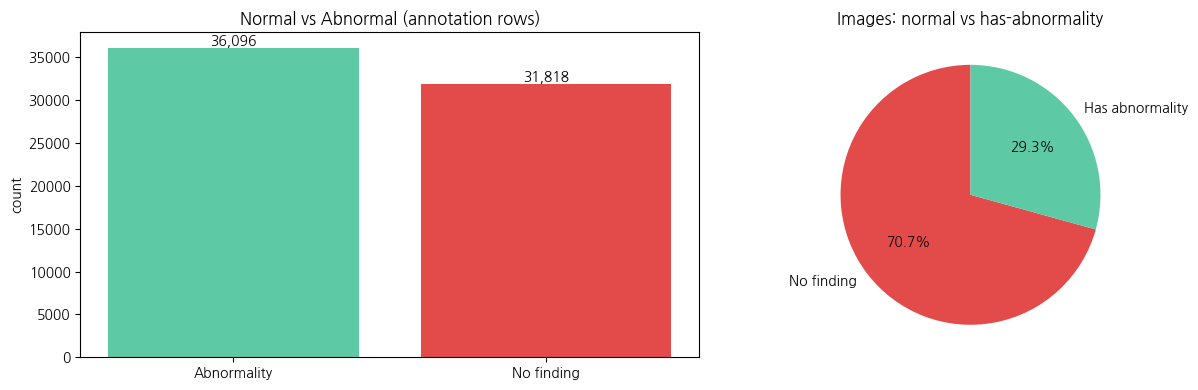

class_name
No finding         10606
Has abnormality     4394
Name: count, dtype: int64

→ 정상 이미지 비율이 높을수록, 모델이 "이상 없음"으로 편향될 위험이 큽니다.


In [7]:
# No finding(정상) 이미지가 전체에서 차지하는 비중을 본다
finding_counts = df['class_name'].apply(
    lambda x: 'No finding' if x == 'No finding' else 'Abnormality'
).value_counts()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].bar(finding_counts.index, finding_counts.values,
          color=['#5DCAA5', '#E24B4A'])
ax[0].set_title('Normal vs Abnormal (annotation rows)')
ax[0].set_ylabel('count')
for i, v in enumerate(finding_counts.values):
    ax[0].text(i, v, f'{v:,}', ha='center', va='bottom')

# 이미지 단위로도 본다 (행 단위와 다를 수 있음)
img_level = df.groupby('image_id')['class_name'].apply(
    lambda s: 'No finding' if (s == 'No finding').all() else 'Has abnormality'
).value_counts()
ax[1].pie(img_level.values, labels=img_level.index, autopct='%1.1f%%',
          colors=['#E24B4A', '#5DCAA5'], startangle=90)
ax[1].set_title('Images: normal vs has-abnormality')

plt.tight_layout(); plt.show()

print(img_level)
print(f'\n→ 정상 이미지 비율이 높을수록, 모델이 "이상 없음"으로 편향될 위험이 큽니다.')

### 3-2. 14개 병변 클래스별 분포 — 어떤 소견이 희귀한가

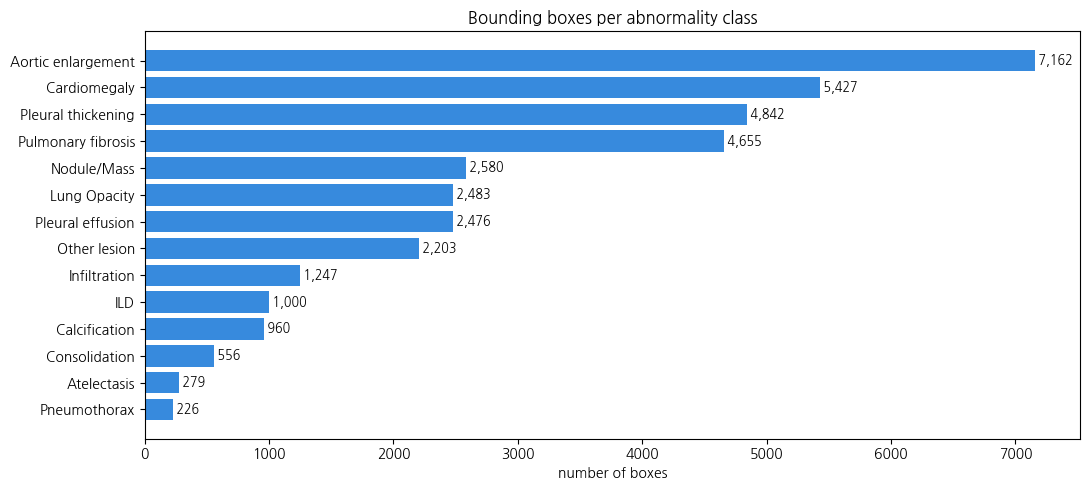

가장 많은 클래스: Aortic enlargement (7,162)
가장 적은 클래스: Pneumothorax (226)

→ 최다/최소 클래스의 개수 차이가 31.7배입니다.
  다중 클래스(도전과제 5)로 가면, 개수가 적은 클래스의 AP가 낮게 나올 것입니다.


In [8]:
# No finding을 제외한 실제 병변만
abn = df[df['class_name'] != 'No finding']

class_counts = abn['class_name'].value_counts()

plt.figure(figsize=(11, 5))
bars = plt.barh(class_counts.index[::-1], class_counts.values[::-1],
                color='#378ADD')
plt.title('Bounding boxes per abnormality class')
plt.xlabel('number of boxes')
for bar in bars:
    w = bar.get_width()
    plt.text(w, bar.get_y() + bar.get_height()/2, f' {int(w):,}',
             va='center', fontsize=9)
plt.tight_layout(); plt.show()

print('가장 많은 클래스:', class_counts.index[0], f'({class_counts.iloc[0]:,})')
print('가장 적은 클래스:', class_counts.index[-1], f'({class_counts.iloc[-1]:,})')
print(f'\n→ 최다/최소 클래스의 개수 차이가 {class_counts.iloc[0]/class_counts.iloc[-1]:.1f}배입니다.')
print('  다중 클래스(도전과제 5)로 가면, 개수가 적은 클래스의 AP가 낮게 나올 것입니다.')

### 3-3. 이미지당 박스 개수 분포

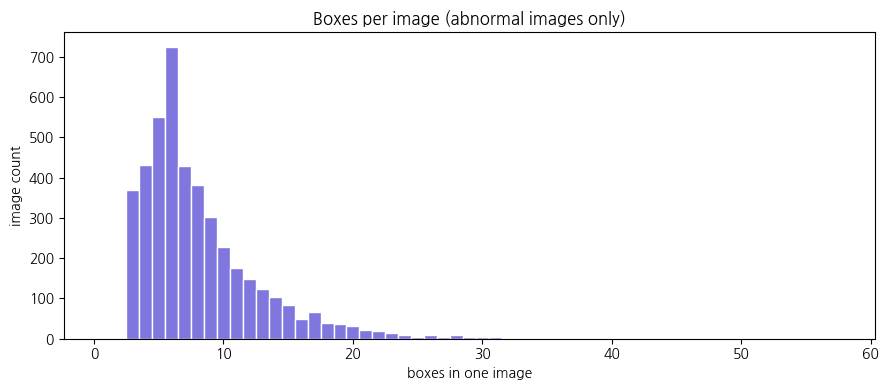

박스가 있는 이미지: 4,394장
이미지당 평균 박스 수: 8.2개
최대: 57개 (한 이미지)


In [9]:
# 이미지마다 박스가 몇 개씩 있는지 (No finding 제외)
boxes_per_img = abn.groupby('image_id').size()

plt.figure(figsize=(9, 4))
plt.hist(boxes_per_img, bins=range(1, boxes_per_img.max()+2),
         color='#7F77DD', edgecolor='white', align='left')
plt.title('Boxes per image (abnormal images only)')
plt.xlabel('boxes in one image'); plt.ylabel('image count')
plt.tight_layout(); plt.show()

print(f'박스가 있는 이미지: {len(boxes_per_img):,}장')
print(f'이미지당 평균 박스 수: {boxes_per_img.mean():.1f}개')
print(f'최대: {boxes_per_img.max()}개 (한 이미지)')

### 3-4. 박스 크기 분포 — 작은 병변이 정말 많은가

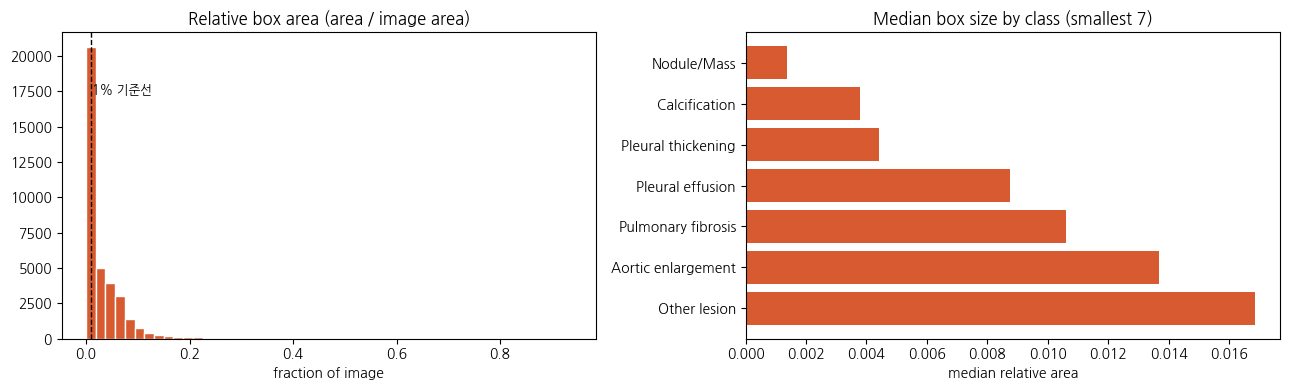

전체 박스의 37.2%가 이미지 면적의 1% 미만인 "작은 병변"입니다.
→ 작은 병변 비중이 높으면, 입력 해상도를 키우는 것(도전과제 1)이 효과적일 수 있습니다.


In [10]:
# 박스의 상대 크기(이미지 대비 면적 비율)를 계산
# 작은 병변(결절/석회화)이 많다면, 해상도(도전과제 1)가 성능에 직접 영향을 준다
abn_valid = abn.dropna(subset=['x_min','y_min','x_max','y_max']).copy()
abn_valid['box_w'] = (abn_valid['x_max'] - abn_valid['x_min']) / abn_valid['width']
abn_valid['box_h'] = (abn_valid['y_max'] - abn_valid['y_min']) / abn_valid['height']
abn_valid['box_area'] = abn_valid['box_w'] * abn_valid['box_h']

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(abn_valid['box_area'], bins=50, color='#D85A30', edgecolor='white')
ax[0].set_title('Relative box area (area / image area)')
ax[0].set_xlabel('fraction of image')
ax[0].axvline(0.01, color='black', ls='--', lw=1)
ax[0].text(0.012, ax[0].get_ylim()[1]*0.8, '1% 기준선', fontsize=9)

# 가장 작은 박스를 갖는 클래스 Top 5
small = abn_valid.groupby('class_name')['box_area'].median().sort_values()
ax[1].barh(small.index[:7][::-1], small.values[:7][::-1], color='#D85A30')
ax[1].set_title('Median box size by class (smallest 7)')
ax[1].set_xlabel('median relative area')
plt.tight_layout(); plt.show()

tiny = (abn_valid['box_area'] < 0.01).mean() * 100
print(f'전체 박스의 {tiny:.1f}%가 이미지 면적의 1% 미만인 "작은 병변"입니다.')
print('→ 작은 병변 비중이 높으면, 입력 해상도를 키우는 것(도전과제 1)이 효과적일 수 있습니다.')

### 3-5. EDA 요약 — 여기서 내린 결론

표를 채우기 전에, 위 그래프들에서 무엇을 읽었는지 한 문장씩 정리합니다. 이 요약이 이후 실험 설계의 근거가 됩니다.

| 관찰 | 수치/사실 | 모델에 줄 영향 | 관련 실험 |
|------|----------|---------------|----------|
| 정상 이미지 비중 | (3-1에서 확인) | 높으면 "이상 없음" 편향 | 도전과제 4 |
| 클래스 불균형 | (3-2에서 확인) | 희귀 클래스 AP 낮음 | 도전과제 5 |
| 작은 병변 비중 | (3-4에서 확인) | 저해상도에서 누락 | 도전과제 1 |
| 방사선사 중복 | (2에서 확인) | 박스 겹침 | (고급) WBF |

> 위 빈칸을 본인 실행 결과 수치로 채워보세요. EDA는 그래프를 그리는 게 목적이 아니라, **결론을 문장으로 남기는 것**이 목적입니다.

## 4. 라벨 변환: CSV → YOLO 포맷

이제 CSV의 절대 좌표(`x_min, y_min, x_max, y_max`)를 YOLO 포맷(정규화된 중심좌표)으로 바꿉니다.

YOLO 한 줄 = `class_id  x_center  y_center  width  height` (뒤 4개는 0~1로 정규화)

**여기가 변환의 핵심이자 버그가 가장 잘 숨는 곳입니다.** 다음 셀에서 변환하고, 그 다음 셀에서 반드시 눈으로 검증합니다.

In [11]:
# No finding 처리: 박스가 없으므로 좌표 변환 대상에서 제외
df_bbox = df[df['class_name'] != 'No finding'].copy()

# 좌표 결측 행 제거 (혹시 No finding 외에 NaN이 있어도 안전하게)
df_bbox = df_bbox.dropna(subset=['x_min','y_min','x_max','y_max'])

# 클래스 ID 결정: 단일 클래스 모드면 전부 0, 아니면 원래 class_id 사용
if SINGLE_CLASS:
    df_bbox['yolo_class'] = 0
else:
    df_bbox['yolo_class'] = df_bbox['class_id'].astype(int)

print(f'변환 대상 박스 수: {len(df_bbox):,}')
print(f'단일 클래스 모드: {SINGLE_CLASS}')

변환 대상 박스 수: 36,096
단일 클래스 모드: True


In [12]:
def make_yolo_label(row):
    """CSV 한 행(절대 좌표) → YOLO 한 줄(정규화 중심좌표)"""
    w_img, h_img = row['width'], row['height']
    # 중심좌표 = (min + max) / 2, 그 다음 이미지 크기로 나눠 0~1로 정규화
    cx = ((row['x_min'] + row['x_max']) / 2) / w_img
    cy = ((row['y_min'] + row['y_max']) / 2) / h_img
    bw = (row['x_max'] - row['x_min']) / w_img
    bh = (row['y_max'] - row['y_min']) / h_img
    return f"{int(row['yolo_class'])} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}"

# image_id별로 여러 박스를 줄바꿈으로 묶어 하나의 라벨 텍스트로
labels = df_bbox.groupby('image_id').apply(
    lambda g: '\n'.join(g.apply(make_yolo_label, axis=1))
)
print(f'라벨이 생성된 이미지 수: {len(labels):,}')
print('\n예시 (첫 이미지의 라벨):')
print(labels.iloc[0])

라벨이 생성된 이미지 수: 4,394

예시 (첫 이미지의 라벨):
0 0.342611 0.240072 0.099284 0.097982
0 0.346517 0.238118 0.086263 0.107096
0 0.342611 0.240072 0.099284 0.097982
0 0.343099 0.239746 0.097005 0.099935
0 0.346517 0.238118 0.086263 0.107096


/tmp/ipykernel_23/501122327.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  labels = df_bbox.groupby('image_id').apply(


## 5. ⭐ 변환 검증: 박스를 이미지에 그려본다

**이 단계를 건너뛰면 안 됩니다.** 4번에서 만든 라벨이 수치상 그럴듯해도, 좌표가 미묘하게 어긋났을 수 있습니다.
예를 들어 x와 y를 바꿔 넣어도 코드는 에러 없이 학습까지 통과합니다. 모델이 엉뚱한 걸 학습하고, 한참 뒤 "성능이 왜 이러지?"가 됩니다.

그래서 변환된 라벨을 **실제 이미지 위에 그려서**, 박스가 병변(혹은 해부학적 구조) 위에 맞게 올라가는지 사람 눈으로 확인합니다.

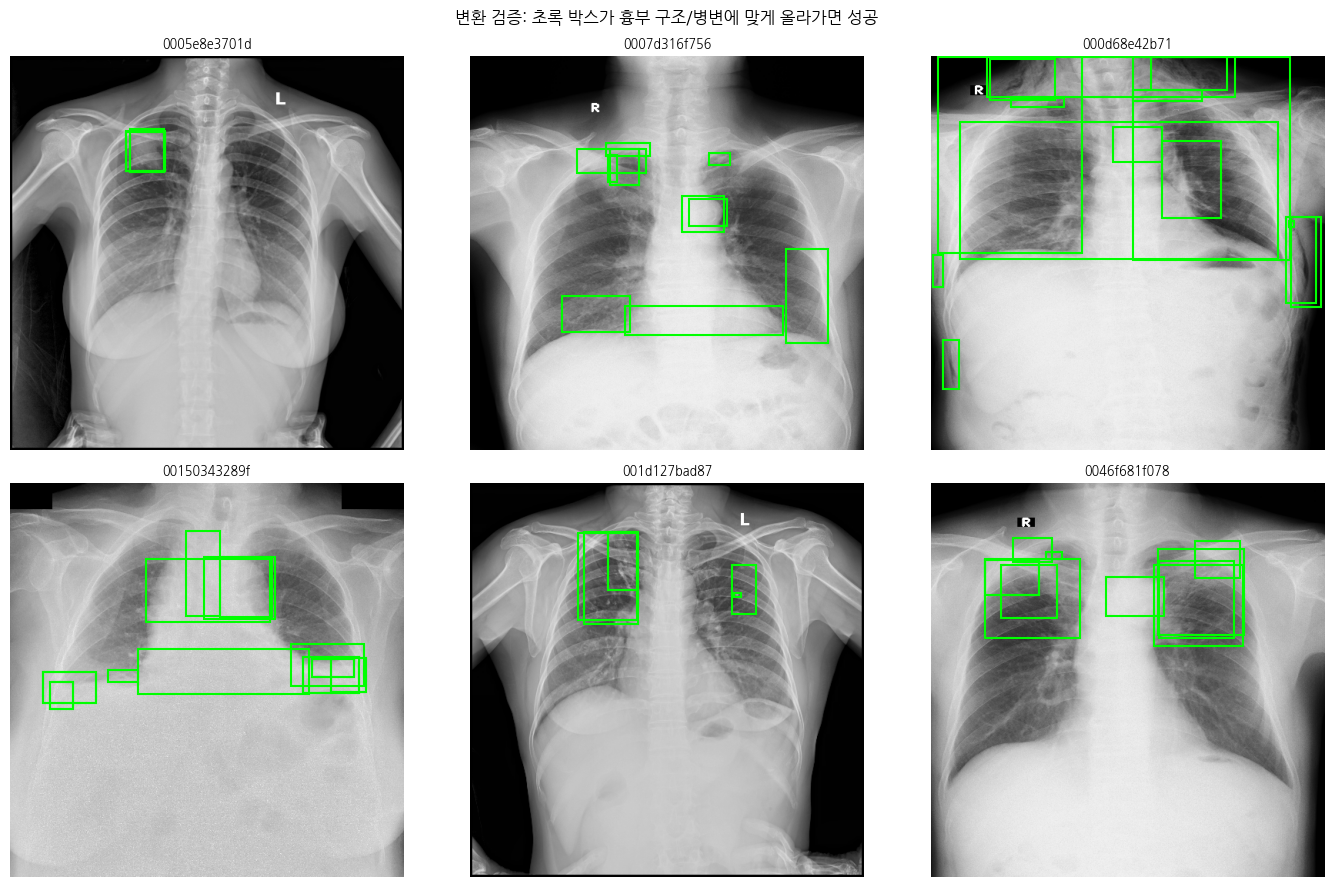

In [13]:
import cv2
import matplotlib.patches as patches

def draw_yolo_boxes(image_id, label_text, ax):
    """YOLO 라벨을 이미지 위에 다시 그려서 검증"""
    img_path = TRAIN_IMG / f'{image_id}.png'
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    ax.imshow(img)
    ax.set_title(image_id[:12], fontsize=9)
    ax.axis('off')

    for line in label_text.strip().split('\n'):
        cls, cx, cy, bw, bh = map(float, line.split())
        # YOLO(정규화 중심좌표) → 픽셀 좌상단좌표로 역변환해서 그림
        abs_w, abs_h = bw * w, bh * h
        x0 = cx * w - abs_w / 2
        y0 = cy * h - abs_h / 2
        rect = patches.Rectangle((x0, y0), abs_w, abs_h,
                                 linewidth=1.5, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)

# 박스가 적당히 있는 이미지 6장을 골라 그린다
sample_ids = labels.index[:6]
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, img_id in zip(axes.flat, sample_ids):
    draw_yolo_boxes(img_id, labels[img_id], ax)
plt.suptitle('변환 검증: 초록 박스가 흉부 구조/병변에 맞게 올라가면 성공', fontsize=12)
plt.tight_layout(); plt.show()

**판단 기준**

- 박스가 흉곽 안쪽, 폐 영역 등 말이 되는 위치에 있으면 → 변환 정확. 다음으로 진행.
- 박스가 이미지 밖으로 나가거나, 위치가 뒤집혀 있거나, 전부 한쪽 구석에 몰려 있으면 → 변환 버그. 4번으로 돌아가 수식을 점검.

> 실무 팁: 이 검증 셀은 한 번 만들어두면 데이터셋이 바뀌어도 재사용합니다. "변환 후 시각 검증"은 객체 탐지 파이프라인의 표준 절차입니다.

## 6. train / val 분할 & 데이터셋 폴더 구성

**이미지 단위로** 분할합니다. 박스 단위로 나누면 같은 이미지가 train과 val 양쪽에 들어가 데이터 누수(leakage)가 생깁니다.

In [14]:
image_ids = labels.index.tolist()
train_ids, val_ids = train_test_split(image_ids, test_size=0.2, random_state=SEED)
print(f'train: {len(train_ids):,}장 | val: {len(val_ids):,}장')

train: 3,515장 | val: 879장


In [15]:
import shutil

# 기존 폴더 정리 후 재생성 (실험 반복 시 깨끗하게)
shutil.rmtree(WORK_DIR, ignore_errors=True)

for split, ids in [('train', train_ids), ('val', val_ids)]:
    (WORK_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
    (WORK_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)

    for img_id in ids:
        src = TRAIN_IMG / f'{img_id}.png'
        dst = WORK_DIR / 'images' / split / f'{img_id}.png'
        if src.exists():
            shutil.copy(src, dst)
        # YOLO는 images 경로의 'images'를 'labels'로 바꿔 라벨을 찾는다
        (WORK_DIR / 'labels' / split / f'{img_id}.txt').write_text(labels[img_id])

print('train 이미지:', len(list((WORK_DIR/'images'/'train').glob('*.png'))))
print('val   이미지:', len(list((WORK_DIR/'images'/'val').glob('*.png'))))

train 이미지: 3515
val   이미지: 879


## 7. data.yaml 생성

YOLO는 이 파일 하나로 데이터셋 구조를 파악합니다. 이미지 경로만 적으면, `images`를 `labels`로 바꿔 라벨을 자동으로 찾습니다.
`SINGLE_CLASS` 설정에 따라 클래스 정의가 달라지므로, 코드로 동적으로 생성합니다.

In [16]:
if SINGLE_CLASS:
    nc = 1
    names = ['abnormality']
else:
    nc = 14
    names = VINBIG_CLASSES

# names를 yaml 리스트 형식 문자열로
names_str = '[' + ', '.join(f"'{n}'" for n in names) + ']'

yaml_content = f"""path: {WORK_DIR.resolve()}
train: images/train
val: images/val

nc: {nc}
names: {names_str}
"""

yaml_path = WORK_DIR / 'data.yaml'
yaml_path.write_text(yaml_content)
print(yaml_content)

path: /kaggle/working/dataset
train: images/train
val: images/val

nc: 1
names: ['abnormality']



## 8. 학습

베이스라인은 epoch=3으로 **파이프라인이 끝까지 도는지** 확인하는 게 목적입니다. 성능은 낮게 나오는 게 정상입니다.
실험(도전과제)에서 이 값들을 하나씩 바꿔가며 성능을 끌어올립니다.

In [17]:
from ultralytics import YOLO

model = YOLO(MODEL_PT)

results = model.train(
    data     = str(yaml_path),
    epochs   = EPOCHS,
    imgsz    = IMG_SIZE,
    batch    = BATCH,
    project  = str(RUN_DIR),
    name     = EXP_NAME,
    exist_ok = True,
    seed     = SEED,
)

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_v3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

## 9. 학습 결과 확인

학습이 끝나면 `runs_cxr/EXP_NAME/` 폴더에 진단용 그래프가 자동 저장됩니다.
loss 곡선만 보지 말고, 아래 그래프들을 함께 읽어야 모델이 어디서 약한지 보입니다.

### 9-1. results.png — loss와 지표의 추세

- **box_loss**: 박스 위치를 얼마나 잘 맞추는가
- **cls_loss**: 클래스를 얼마나 잘 분류하는가
- **dfl_loss**: 박스 경계 분포 정밀도

세 곡선이 **아직 내려가는 중**이면 → 학습을 더 시킬 여지가 있음 (도전과제 3).
**평평**해졌으면 → 그 지점 이후로는 epoch을 늘려도 의미가 적음.

같은 그림 안에 mAP50, mAP50-95 곡선도 있습니다. loss는 내려가는데 mAP가 안 오르면 과적합 신호일 수 있습니다.

### 9-2. confusion_matrix.png — 무엇을 무엇으로 헷갈리는가

모델이 어떤 클래스를 어떤 클래스로 착각하는지 보여줍니다.
- 대각선이 진하면 잘 맞추는 것.
- **배경(background) 행/열**을 특히 봅니다. 병변을 background로 놓치면 recall 문제, background를 병변으로 잡으면 거짓양성 문제입니다.
- 단일 클래스(베이스라인)에서는 abnormality vs background 2×2라 거짓양성/누락 비율이 바로 보입니다.

### 9-3. PR_curve.png — 정밀도-재현율 트레이드오프

곡선 아래 면적이 AP입니다. 곡선이 오른쪽 위에 붙을수록 좋습니다.
곡선이 일찍 꺾여 내려가면, recall을 높이려 할 때 precision이 급격히 무너진다는 뜻입니다.

### 9-4. (다중 클래스 시) 클래스별 지표

도전과제 5처럼 14개 클래스로 가면 클래스별 PR 곡선과 confusion matrix가 더 중요해집니다.
어떤 병변의 AP가 낮은지 보고, 3-2에서 본 클래스 개수와 연결해서 해석합니다.

> 📂 파일명 주의: YOLOv8은 곡선 파일 앞에 `Box`가 붙습니다. `PR_curve.png`가 아니라 **`BoxPR_curve.png`**, F1은 **`BoxF1_curve.png`**입니다. 아래 셀은 이 이름으로 불러옵니다.

=== results.png ===


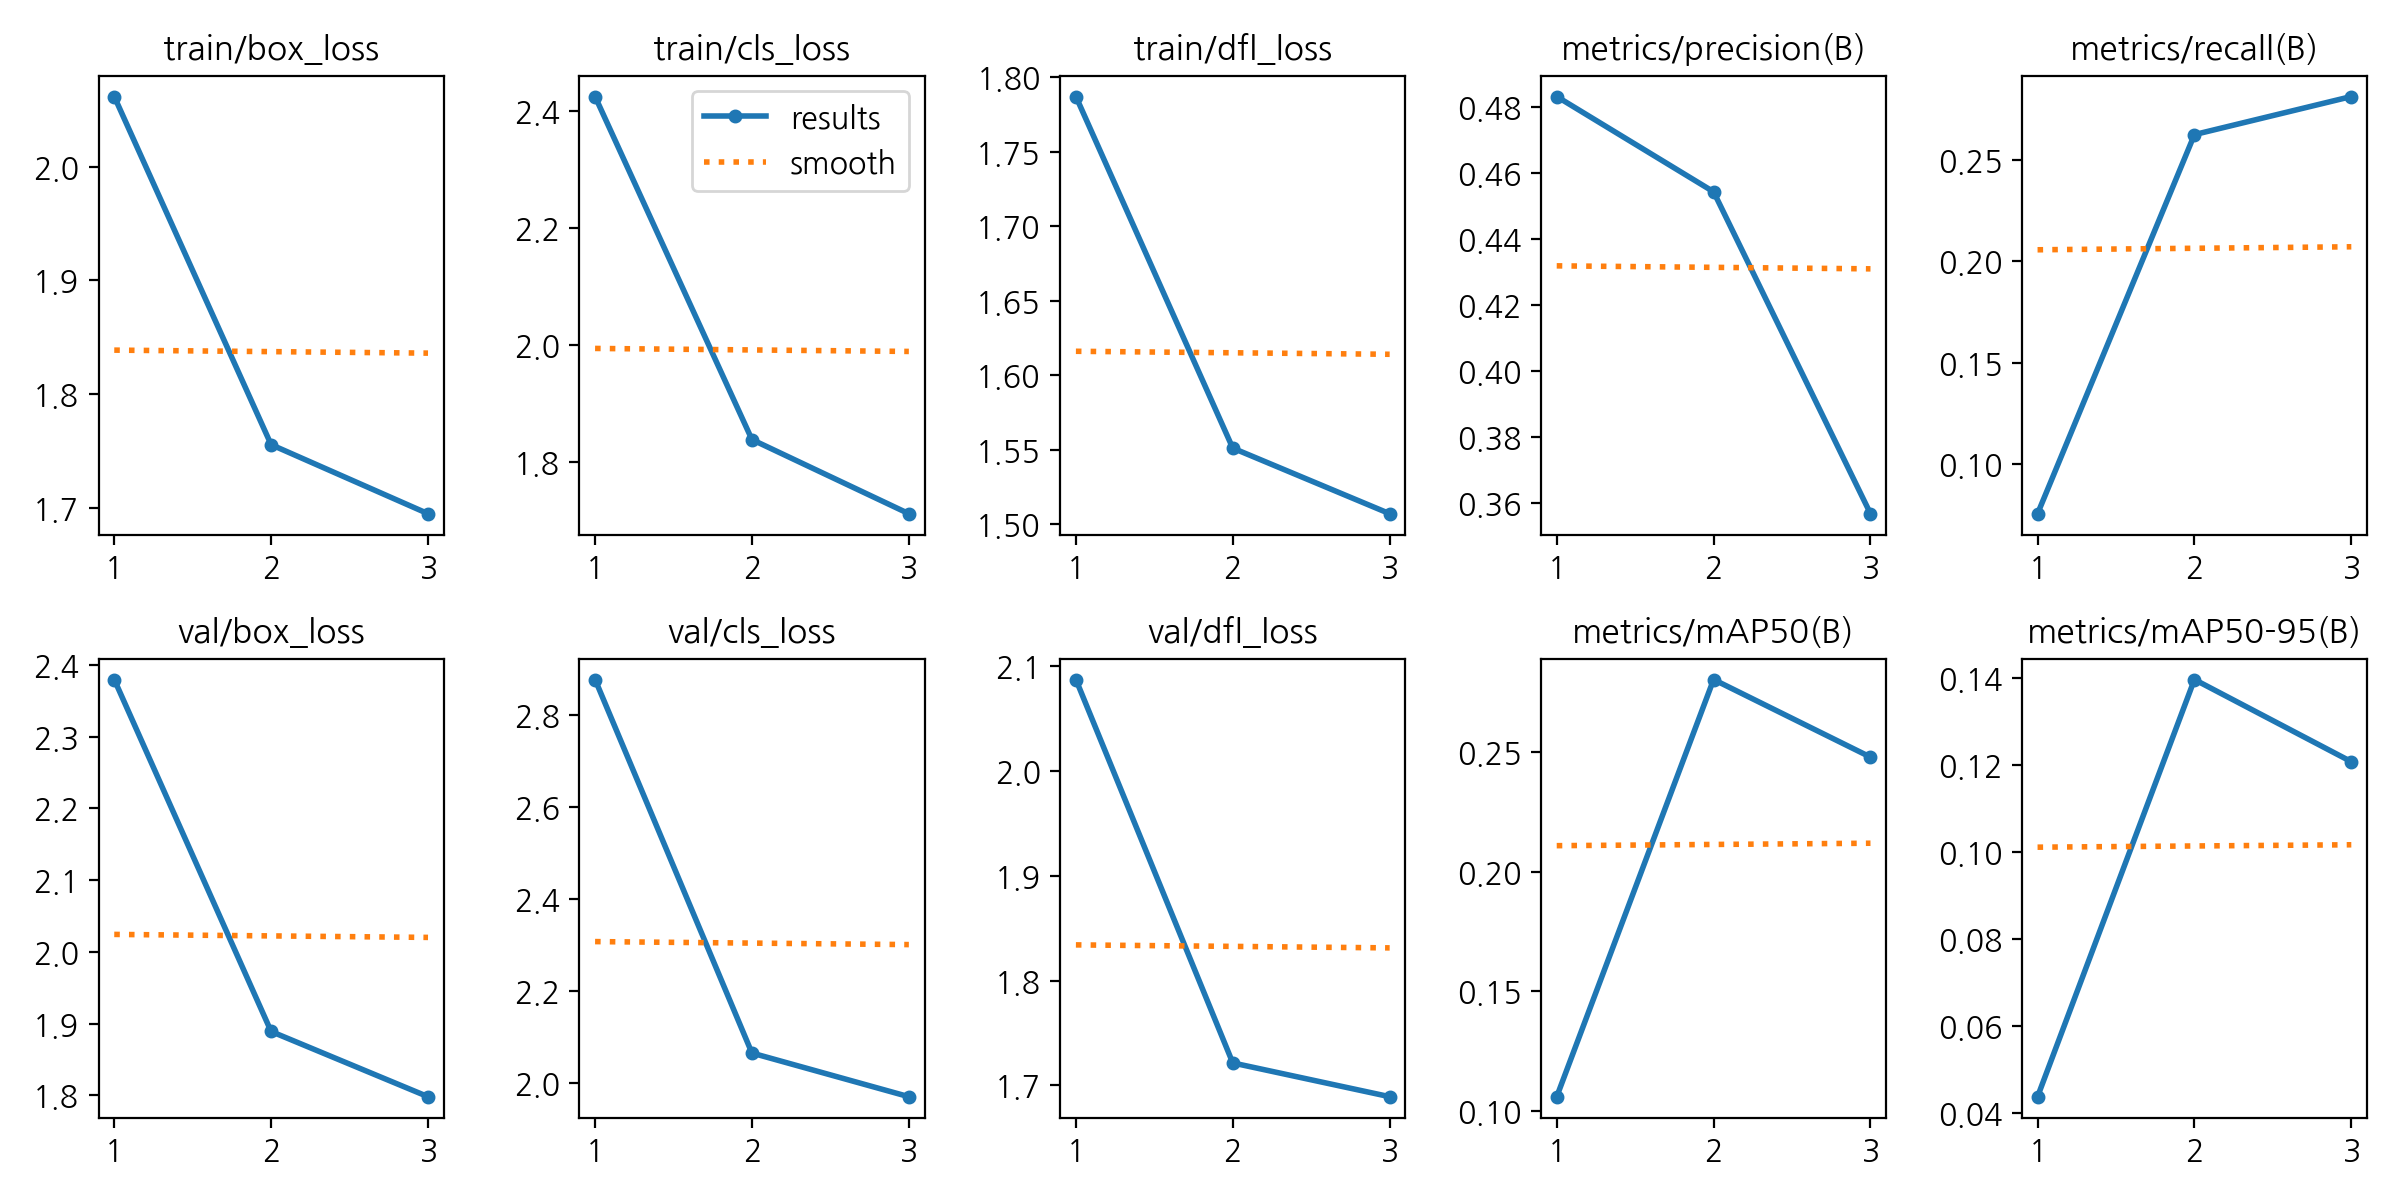

=== confusion_matrix_normalized.png ===


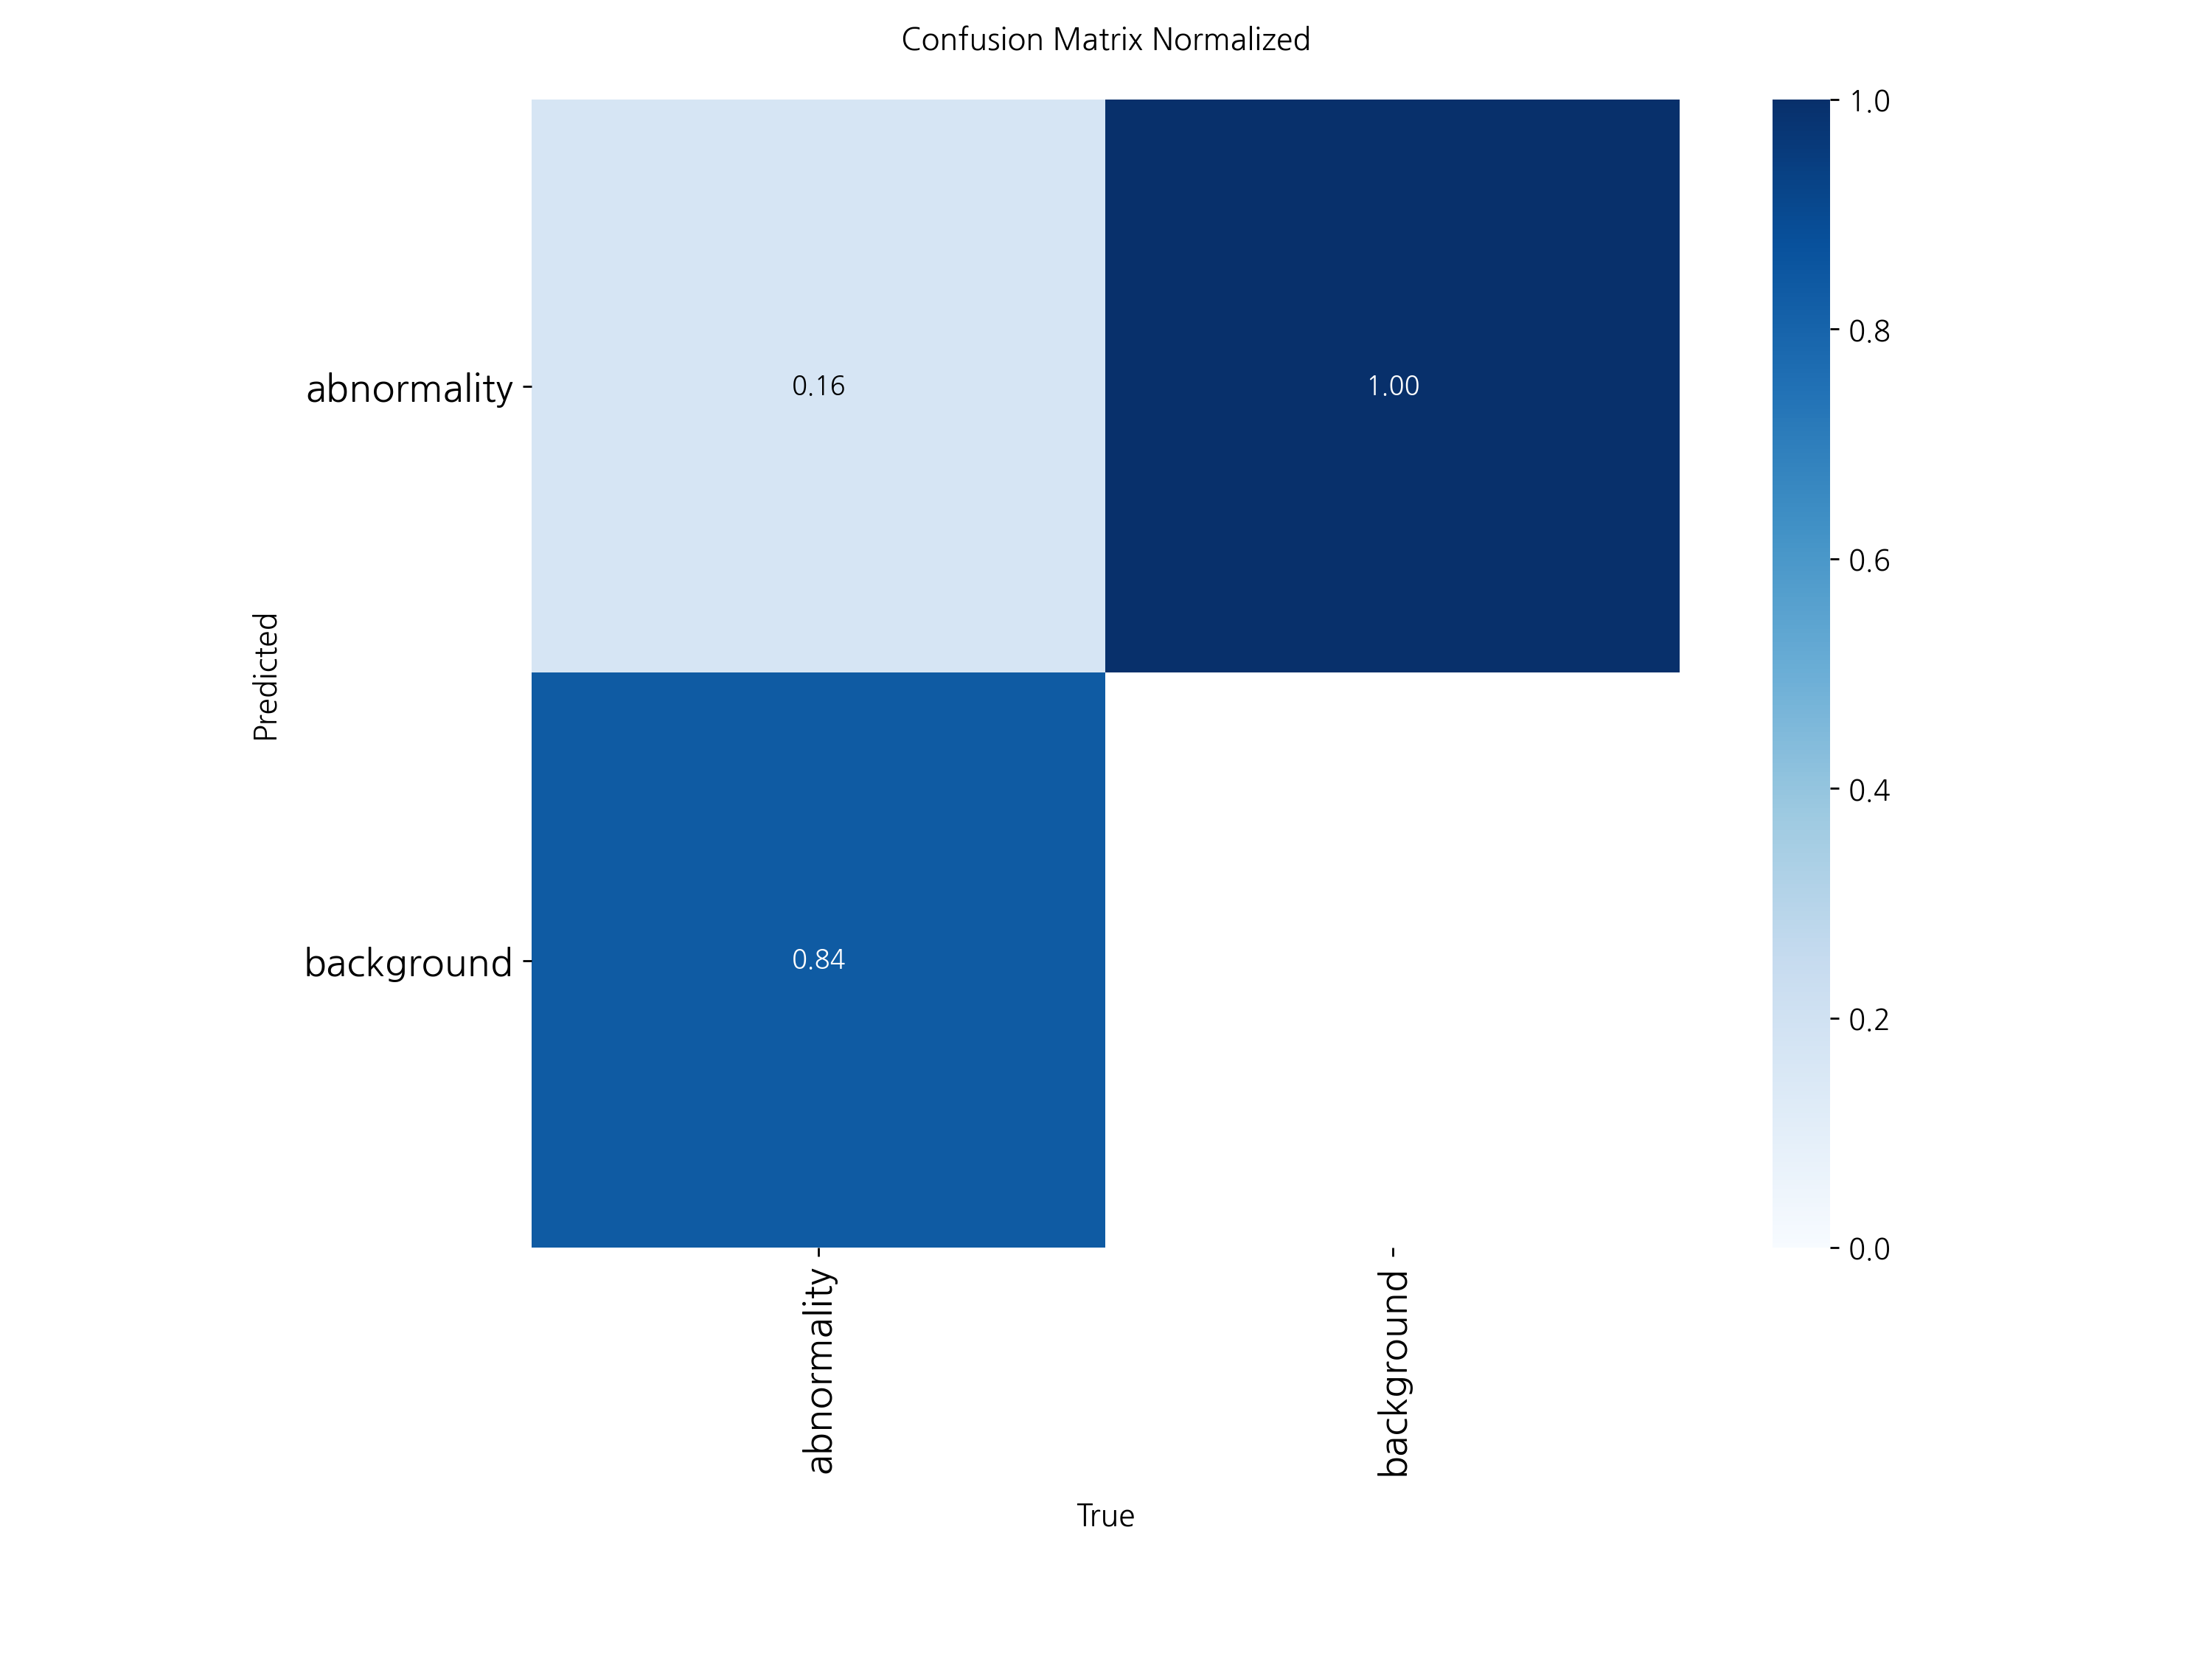

=== BoxPR_curve.png ===


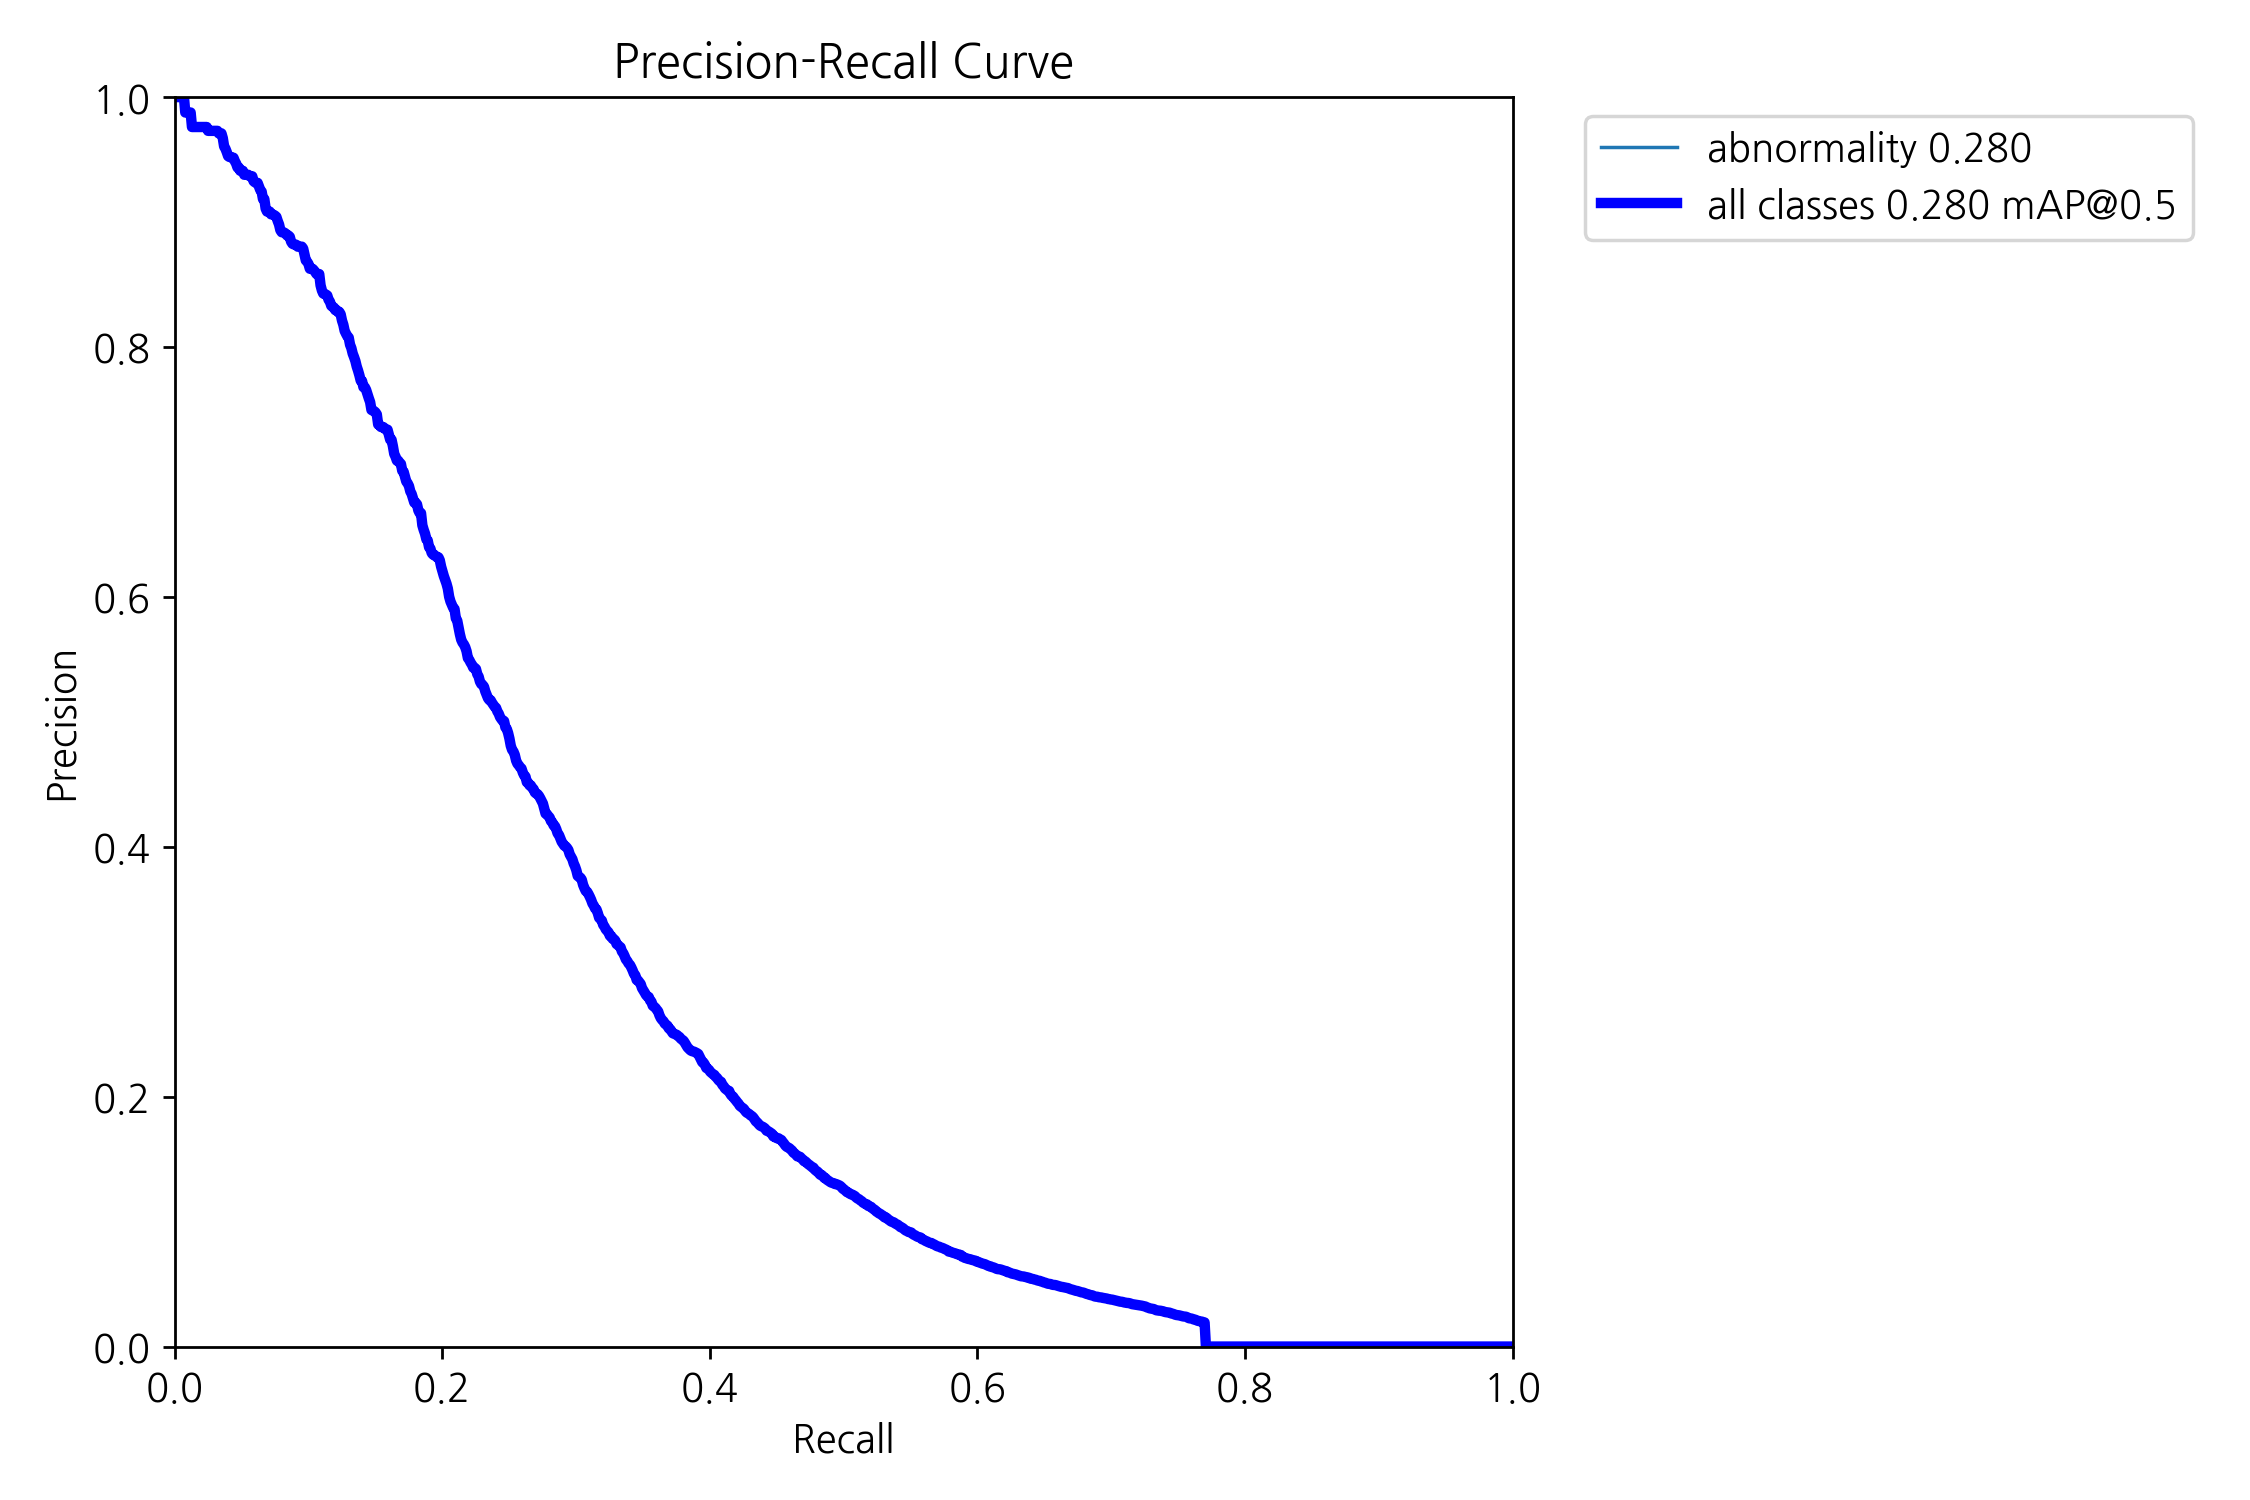

=== BoxF1_curve.png ===


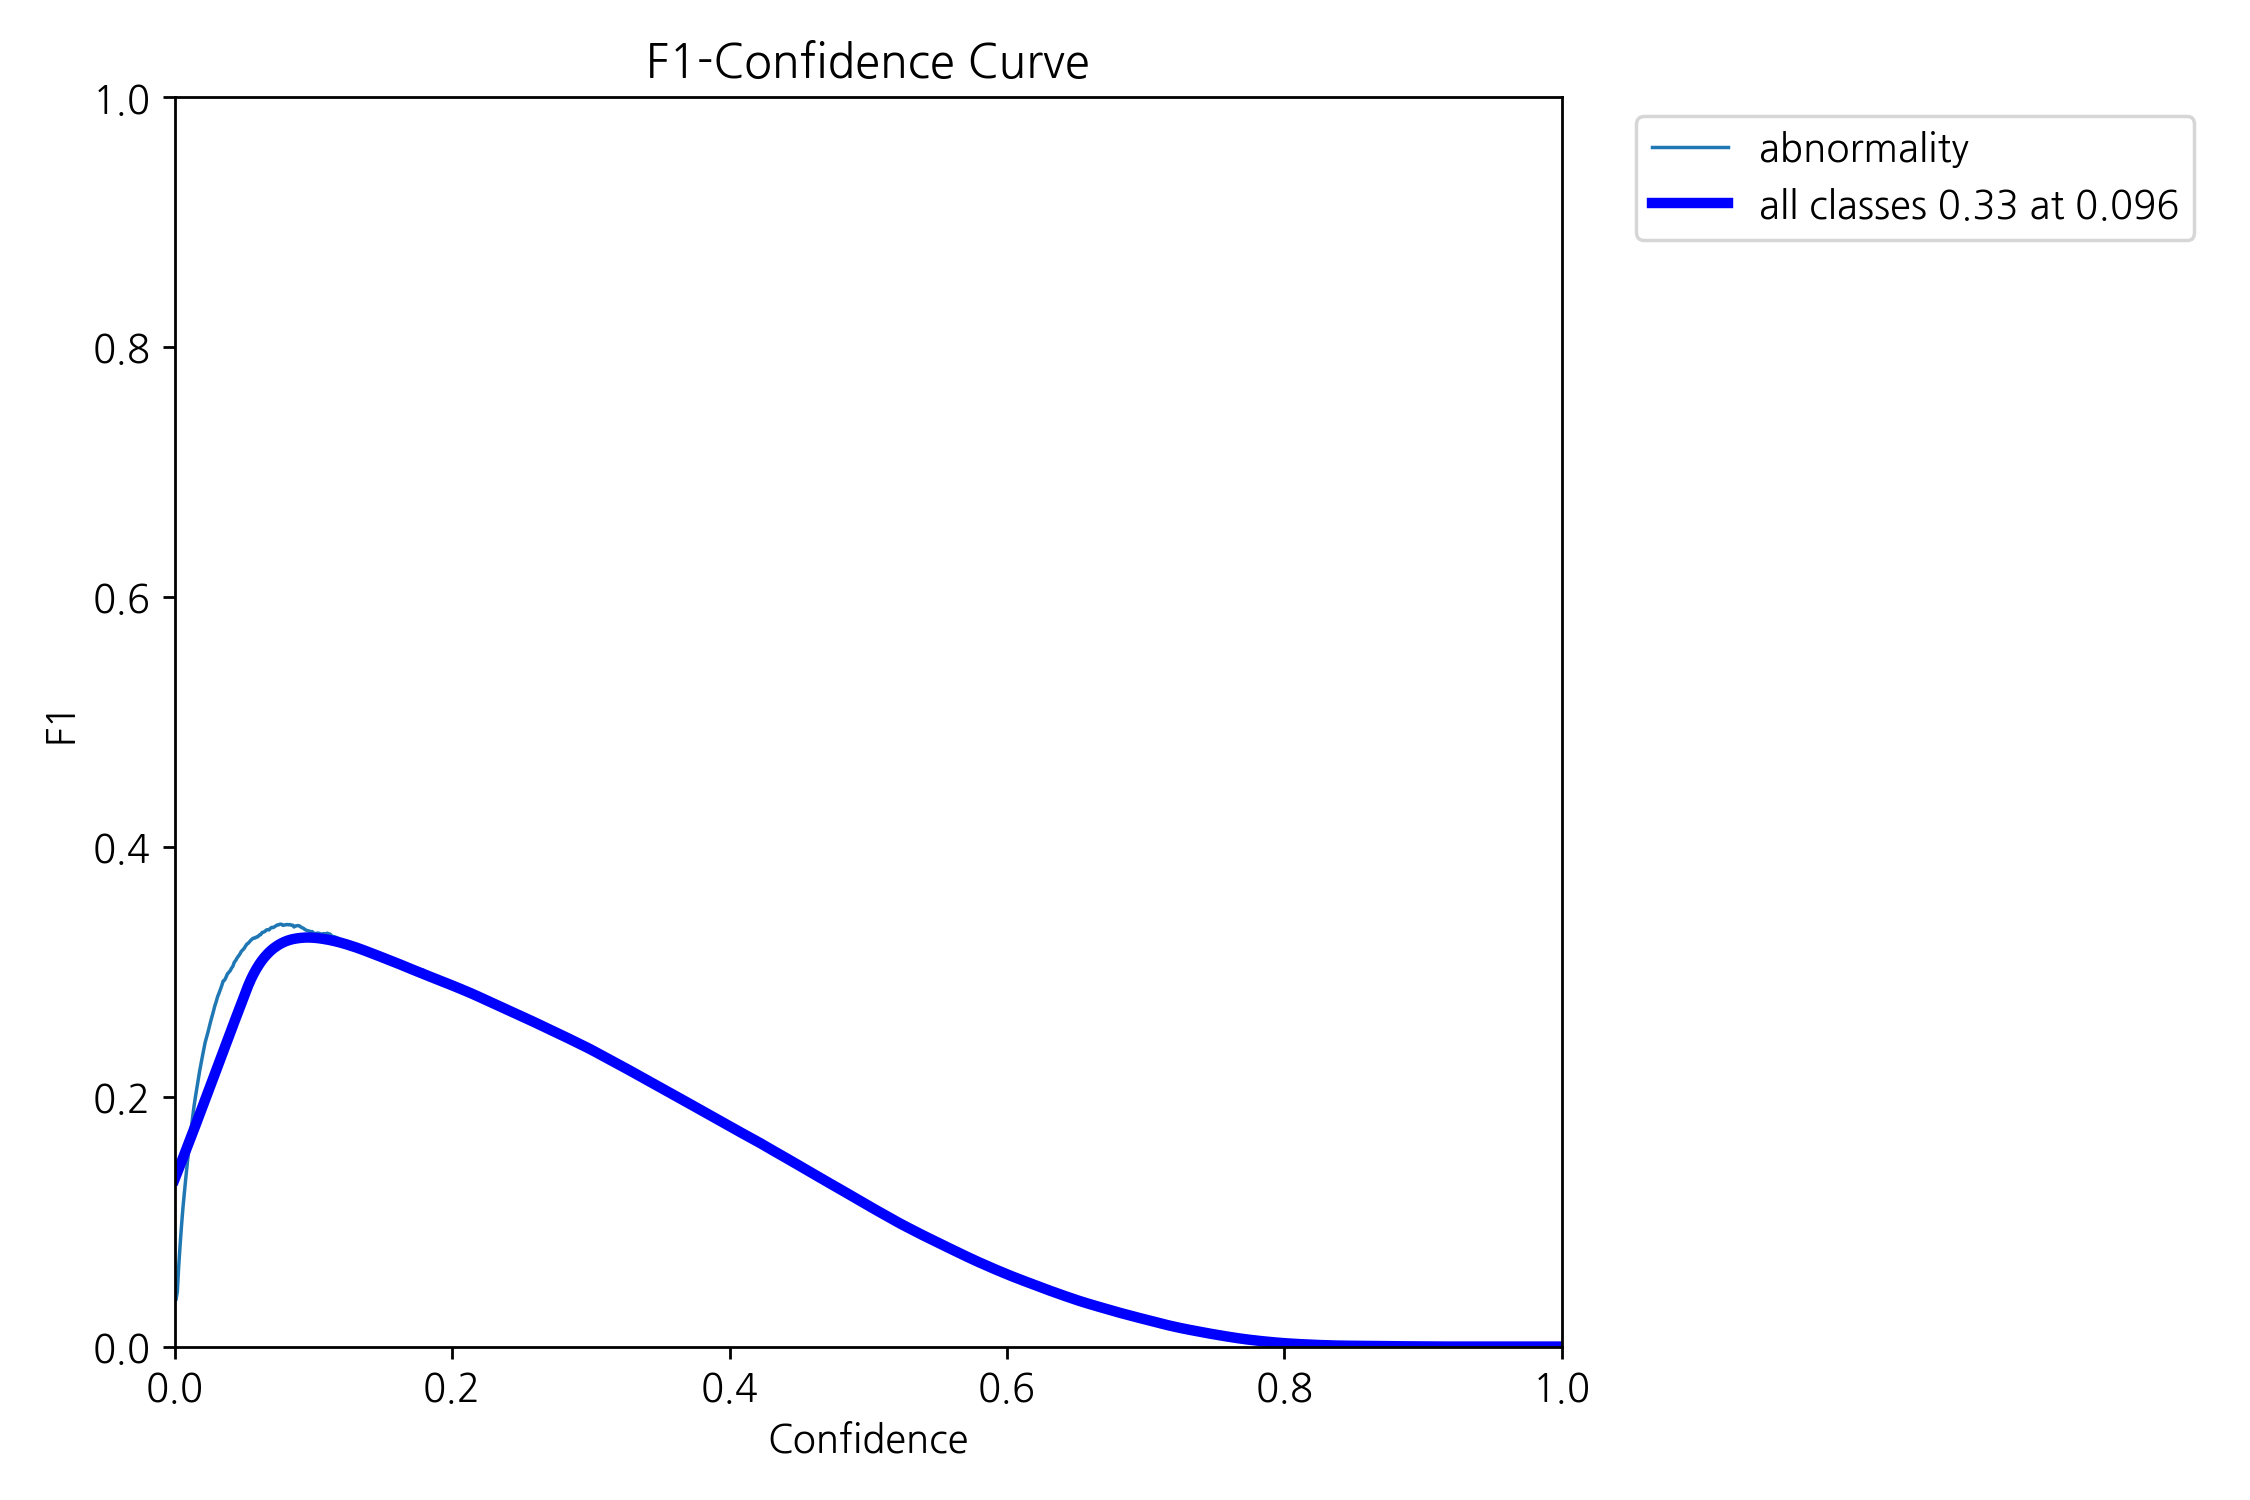

In [18]:
from IPython.display import Image as IPImage, display

# ⚠️ YOLOv8은 곡선 파일명 앞에 'Box'가 붙습니다 (PR_curve가 아니라 BoxPR_curve).
#    또 confusion_matrix는 normalized 버전이 해석에 더 편합니다.
out = RUN_DIR / EXP_NAME

graphs = [
    'results.png',                      # loss & 지표 추세
    'confusion_matrix_normalized.png',  # 정답 vs 예측 혼동 (비율)
    'BoxPR_curve.png',                  # PR 곡선 (곡선 아래 면적 = AP)
    'BoxF1_curve.png',                  # F1 곡선 (best confidence 판단)
]
for name in graphs:
    p = out / name
    if p.exists():
        print(f'=== {name} ===')
        display(IPImage(str(p)))
    else:
        print(f'(없음) {name}  ← 파일명/경로를 확인하세요')

## 10. 성능 평가

### 미션: 4개 지표의 의미를 알고 본다

- **mAP50**: IoU 0.5 기준 평균 정밀도. 가장 흔히 보는 지표.
- **mAP50-95**: IoU 0.5~0.95 평균. 더 엄격하고, 박스 정밀도까지 본다.
- **Precision**: 모델이 "있다"고 한 것 중 실제로 맞은 비율 (거짓양성 관련).
- **Recall**: 실제 병변 중 모델이 잡아낸 비율 (놓침 관련). **의료에서는 보통 recall이 더 중요합니다** — 병변을 놓치는 게 더 위험합니다.

In [19]:
best_model = YOLO(str(RUN_DIR / EXP_NAME / 'weights' / 'best.pt'))
metrics = best_model.val(data=str(yaml_path))

print(f'mAP50     : {metrics.box.map50:.4f}')
print(f'mAP50-95  : {metrics.box.map:.4f}')
print(f'Precision : {metrics.box.mp:.4f}')
print(f'Recall    : {metrics.box.mr:.4f}')
print()
print('이 4개 숫자를 과제 마크다운의 결과표에 기록하세요.')

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2362.0±632.6 MB/s, size: 128.1 KB)
val: Scanning /kaggle/working/dataset/labels/val.cache... 879 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 879/879 307.2Mit/s 0.0s
val: /kaggle/working/dataset/images/val/008b3176a7248a0a189b5731ac8d2e95.png: 2 duplicate labels removed
val: /kaggle/working/dataset/images/val/01570ee44031e4ebab6031501293bf66.png: 1 duplicate labels removed
val: /kaggle/working/dataset/images/val/01a3c3d994d85ce5634d2d13c03fd4b0.png: 3 duplicate labels removed
val: /kaggle/working/dataset/images/val/01b0510a8d3b0860429536653db5eb21.png: 2 duplicate labels removed
val: /kaggle/working/dataset/images/val/023a8b8557d1fd59f272c63be6f3d4c0.png: 1 duplicate labels removed
val: /kaggle/working/dataset/images/val/024f9140bd829c346fc91fcf4009d251.png: 10 duplicat

=== val_batch0_labels.jpg  [정답(GT)] ===


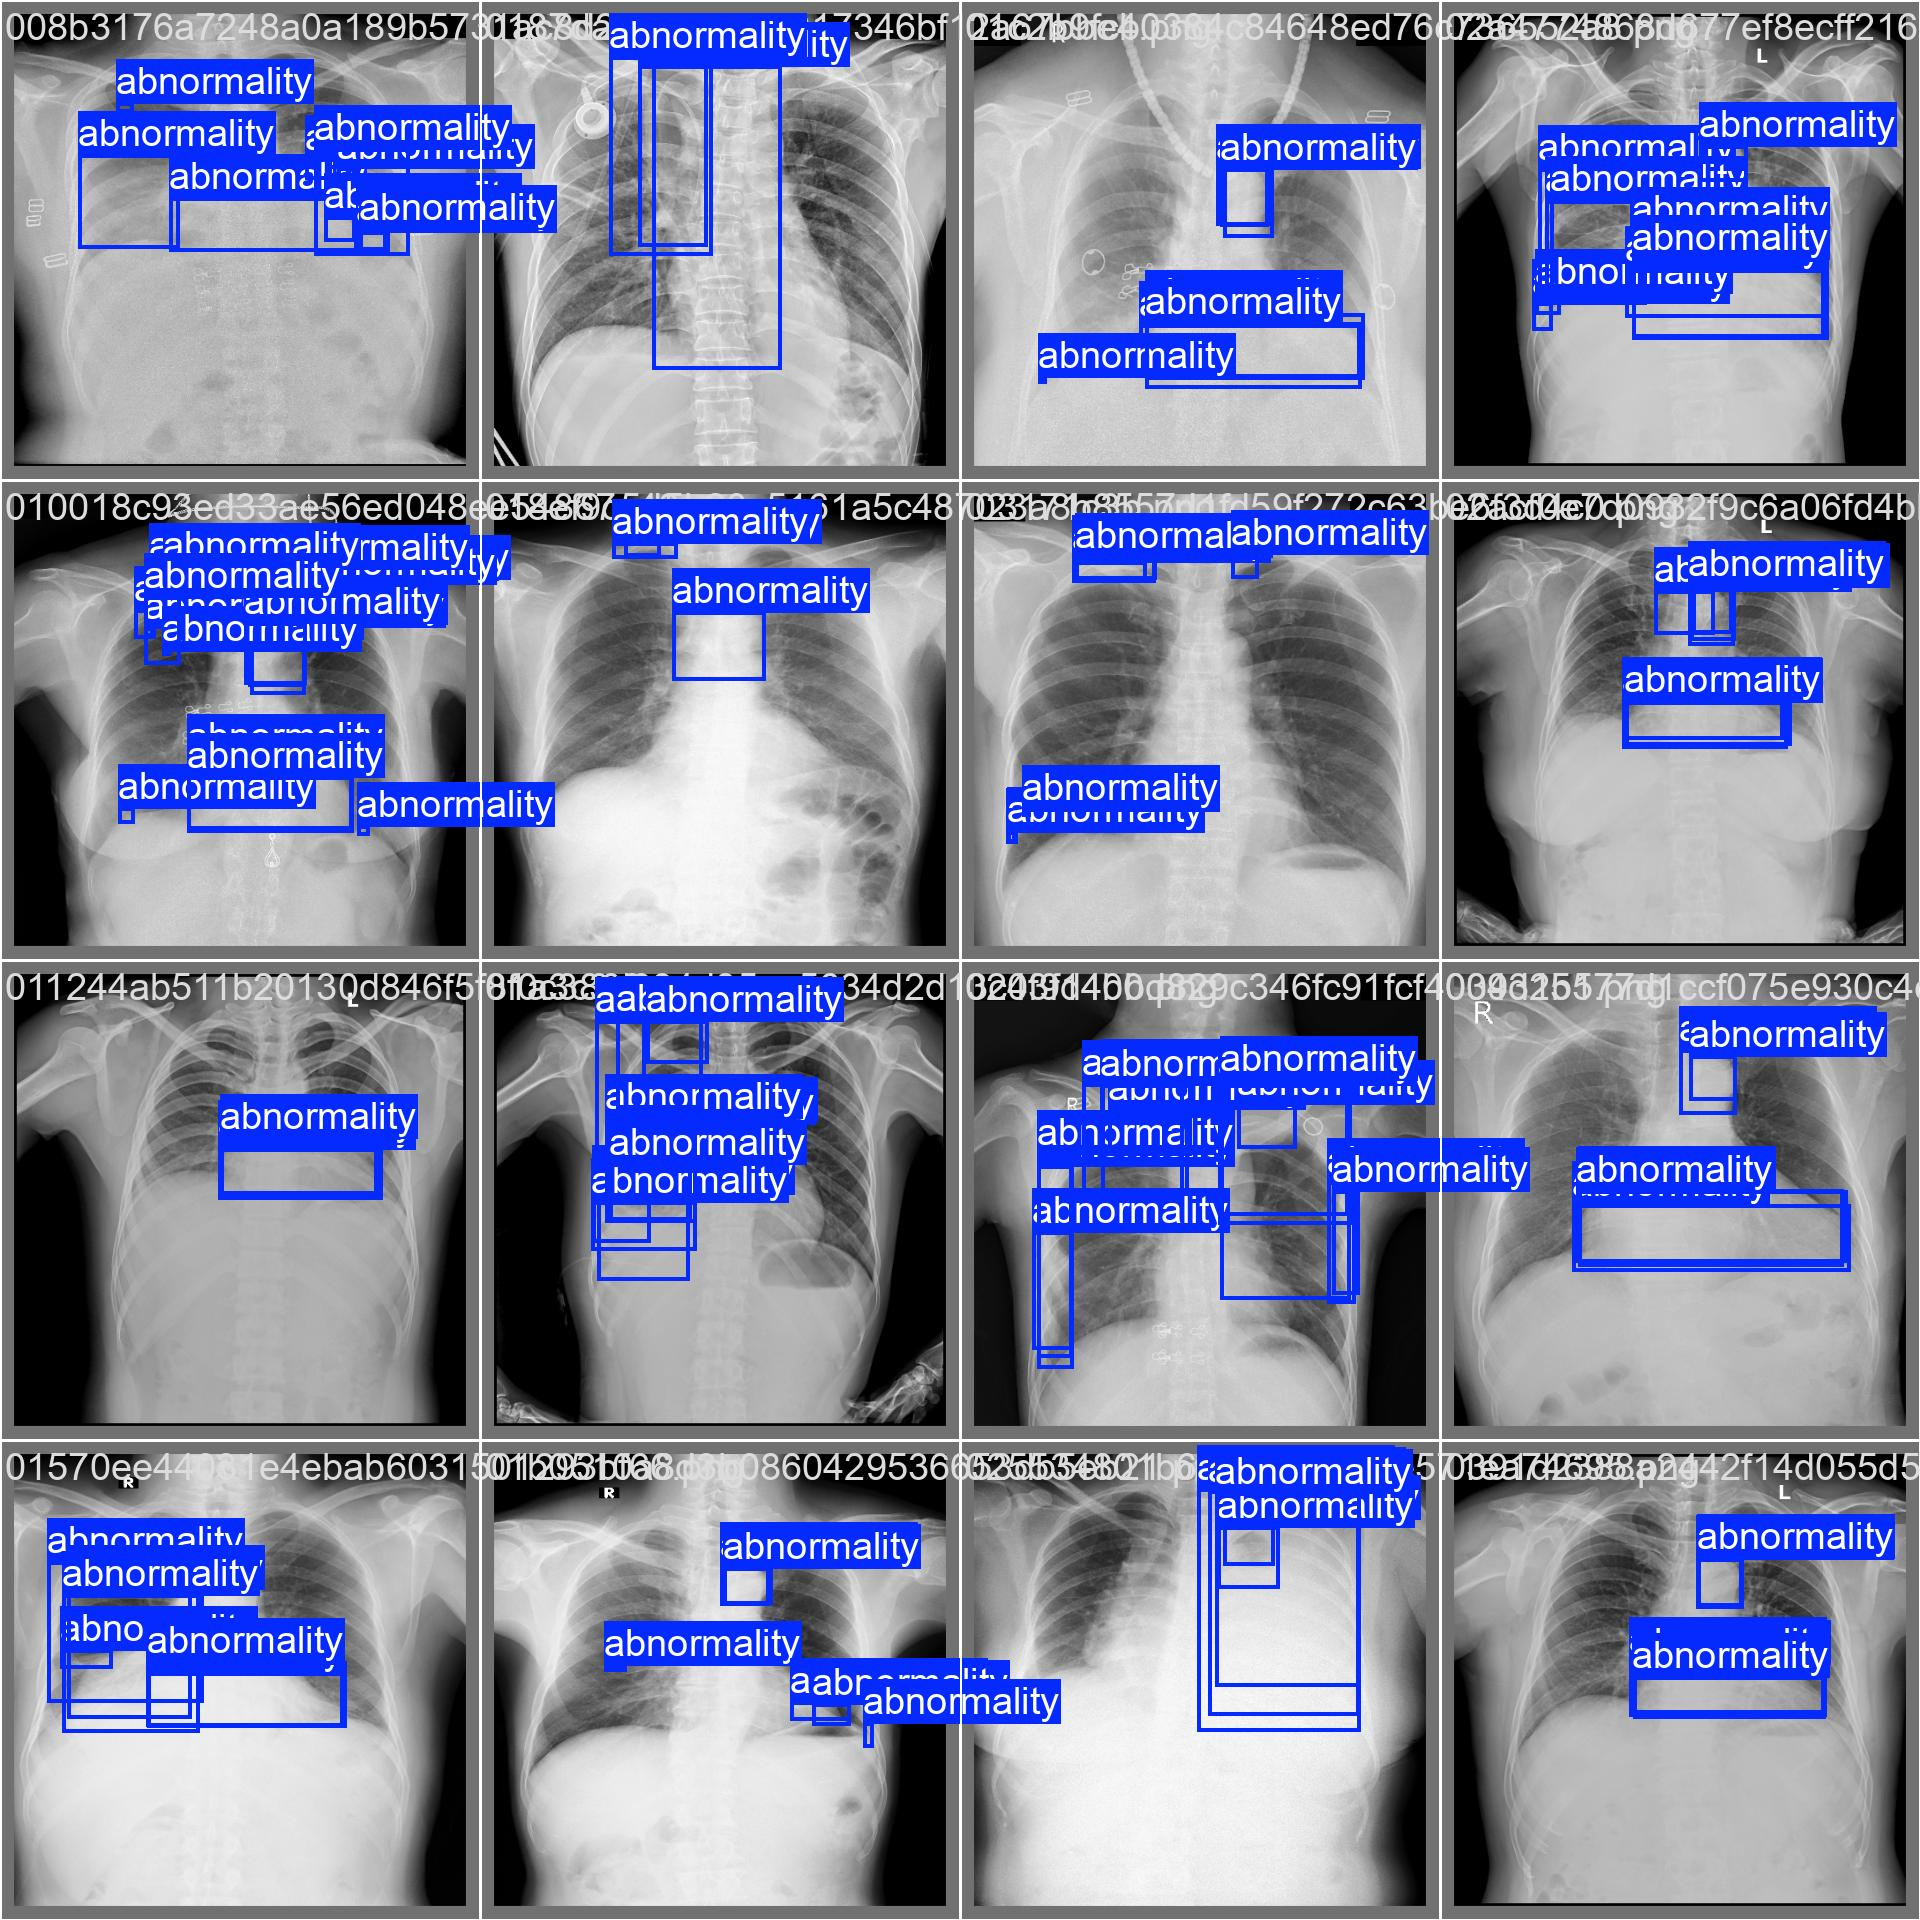

=== val_batch0_pred.jpg  [예측(Pred)] ===


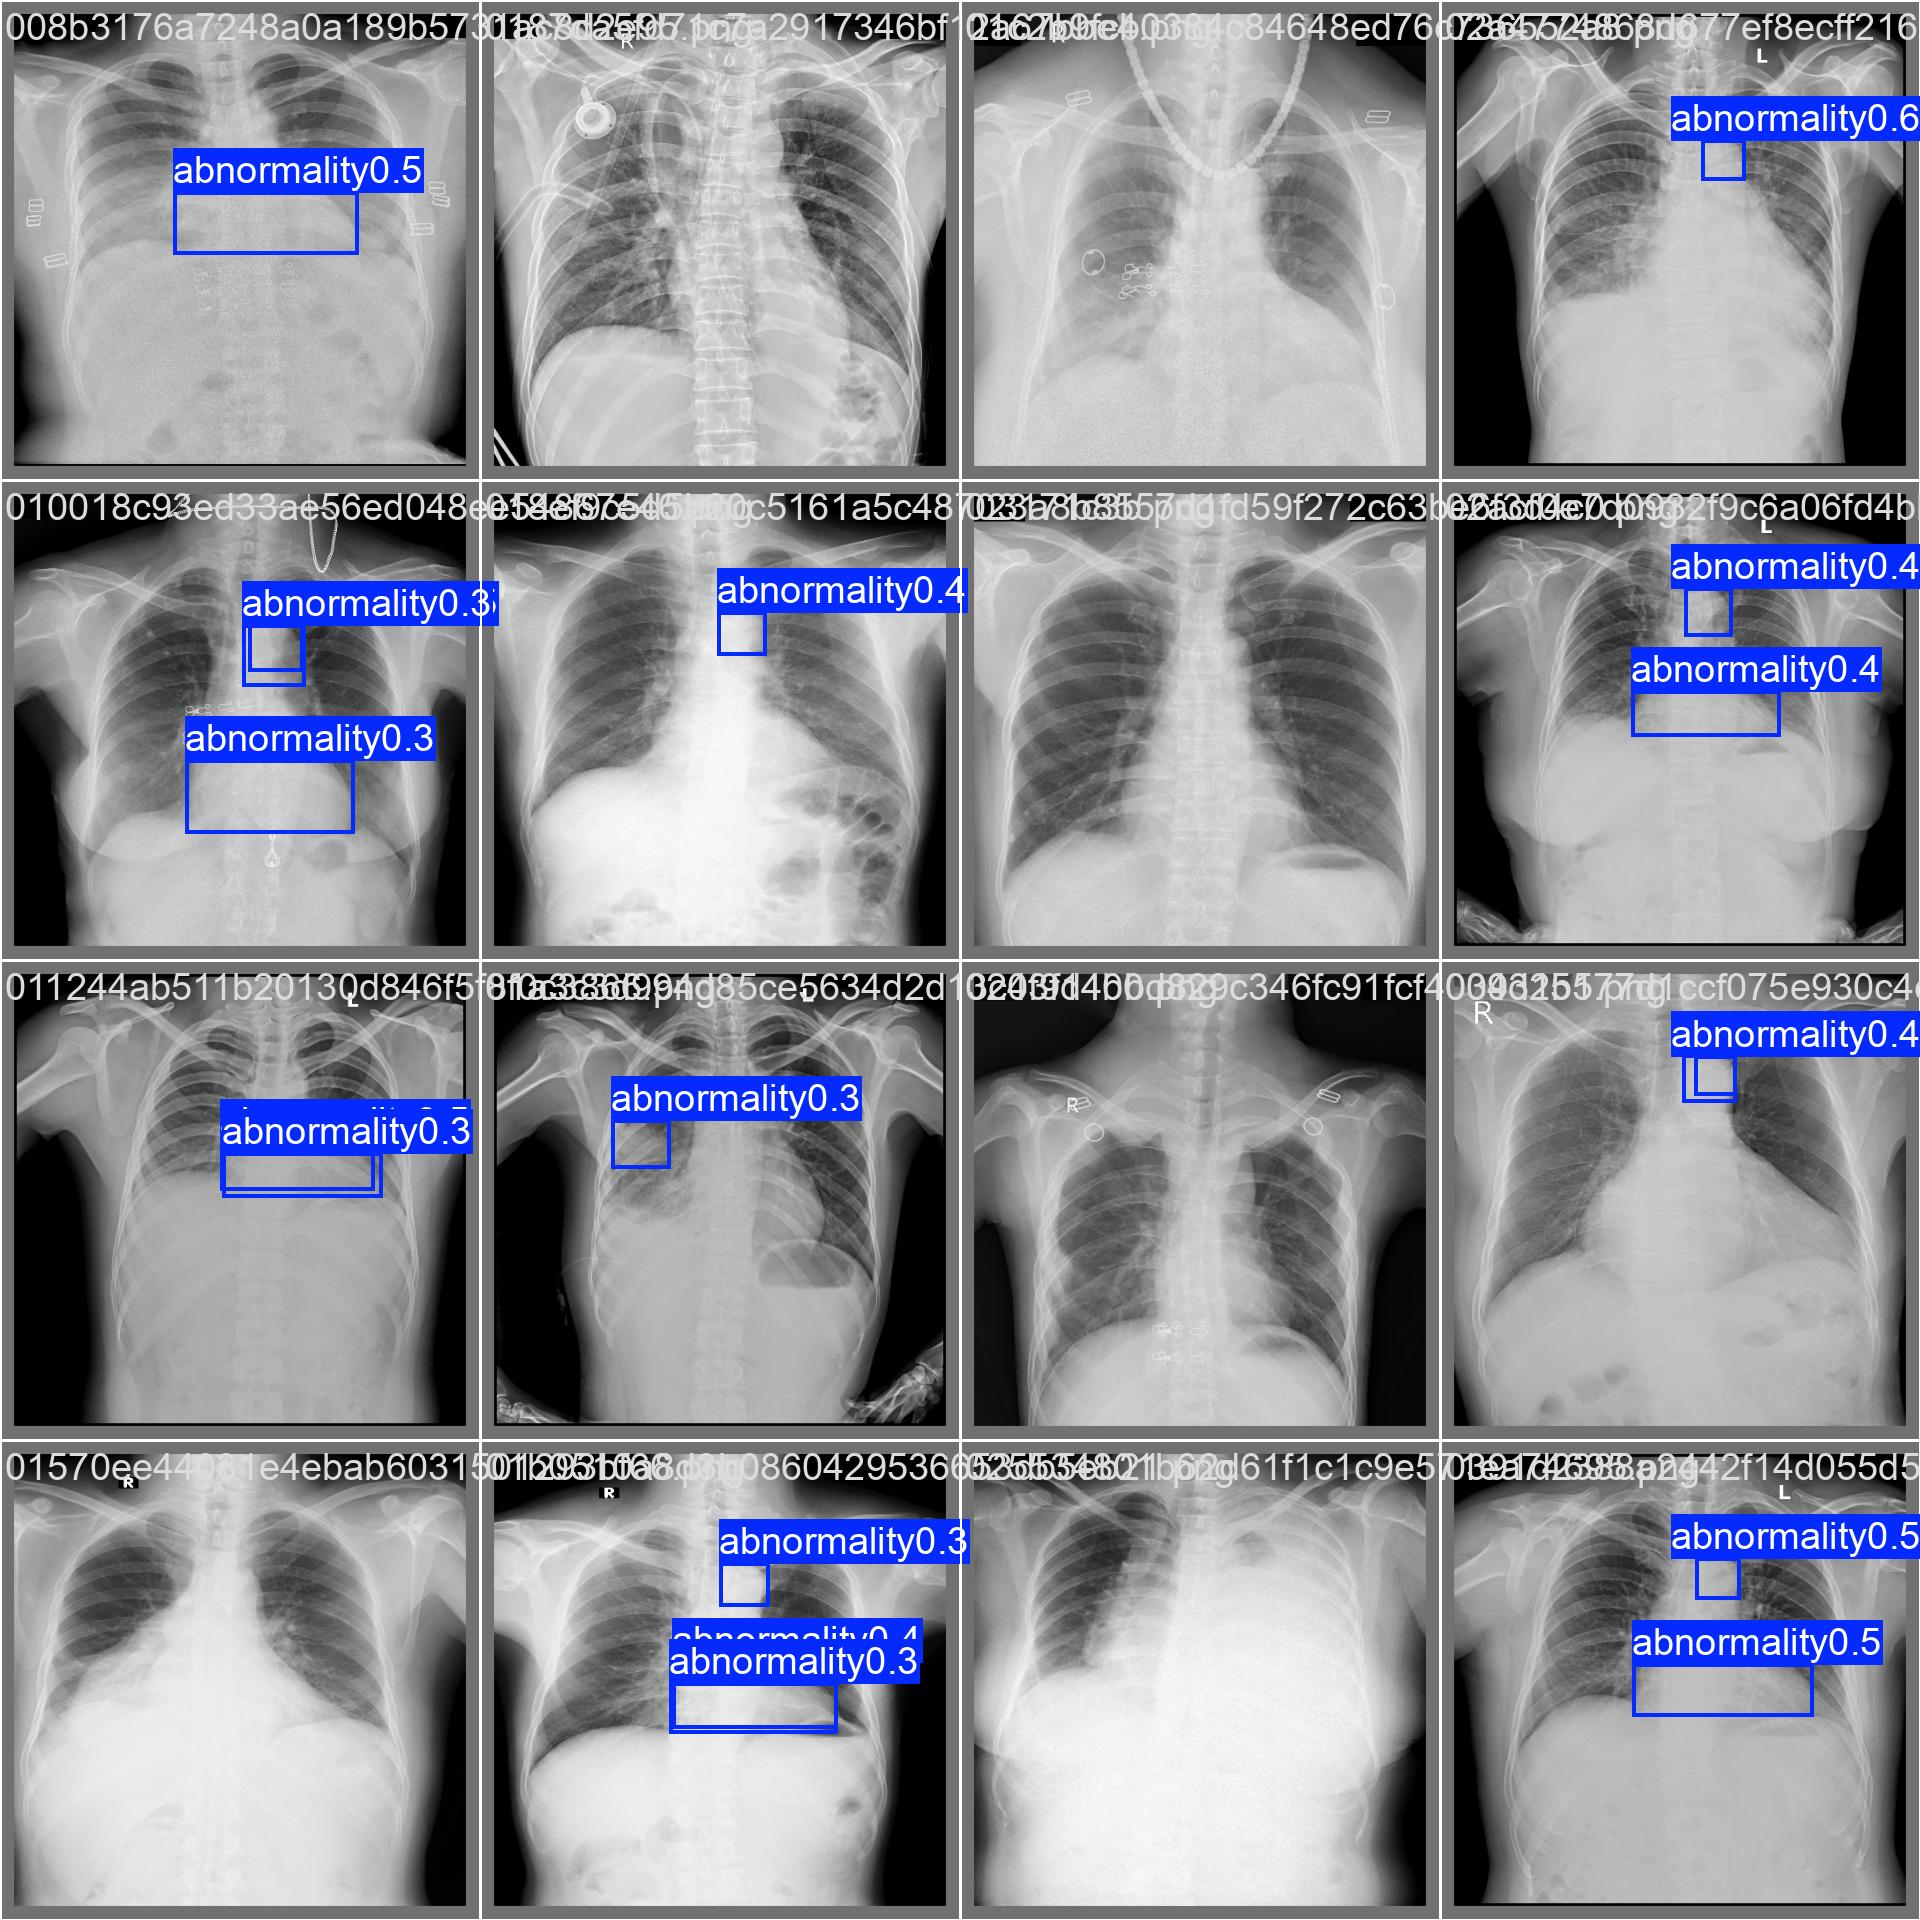

=== val_batch1_labels.jpg  [정답(GT)] ===


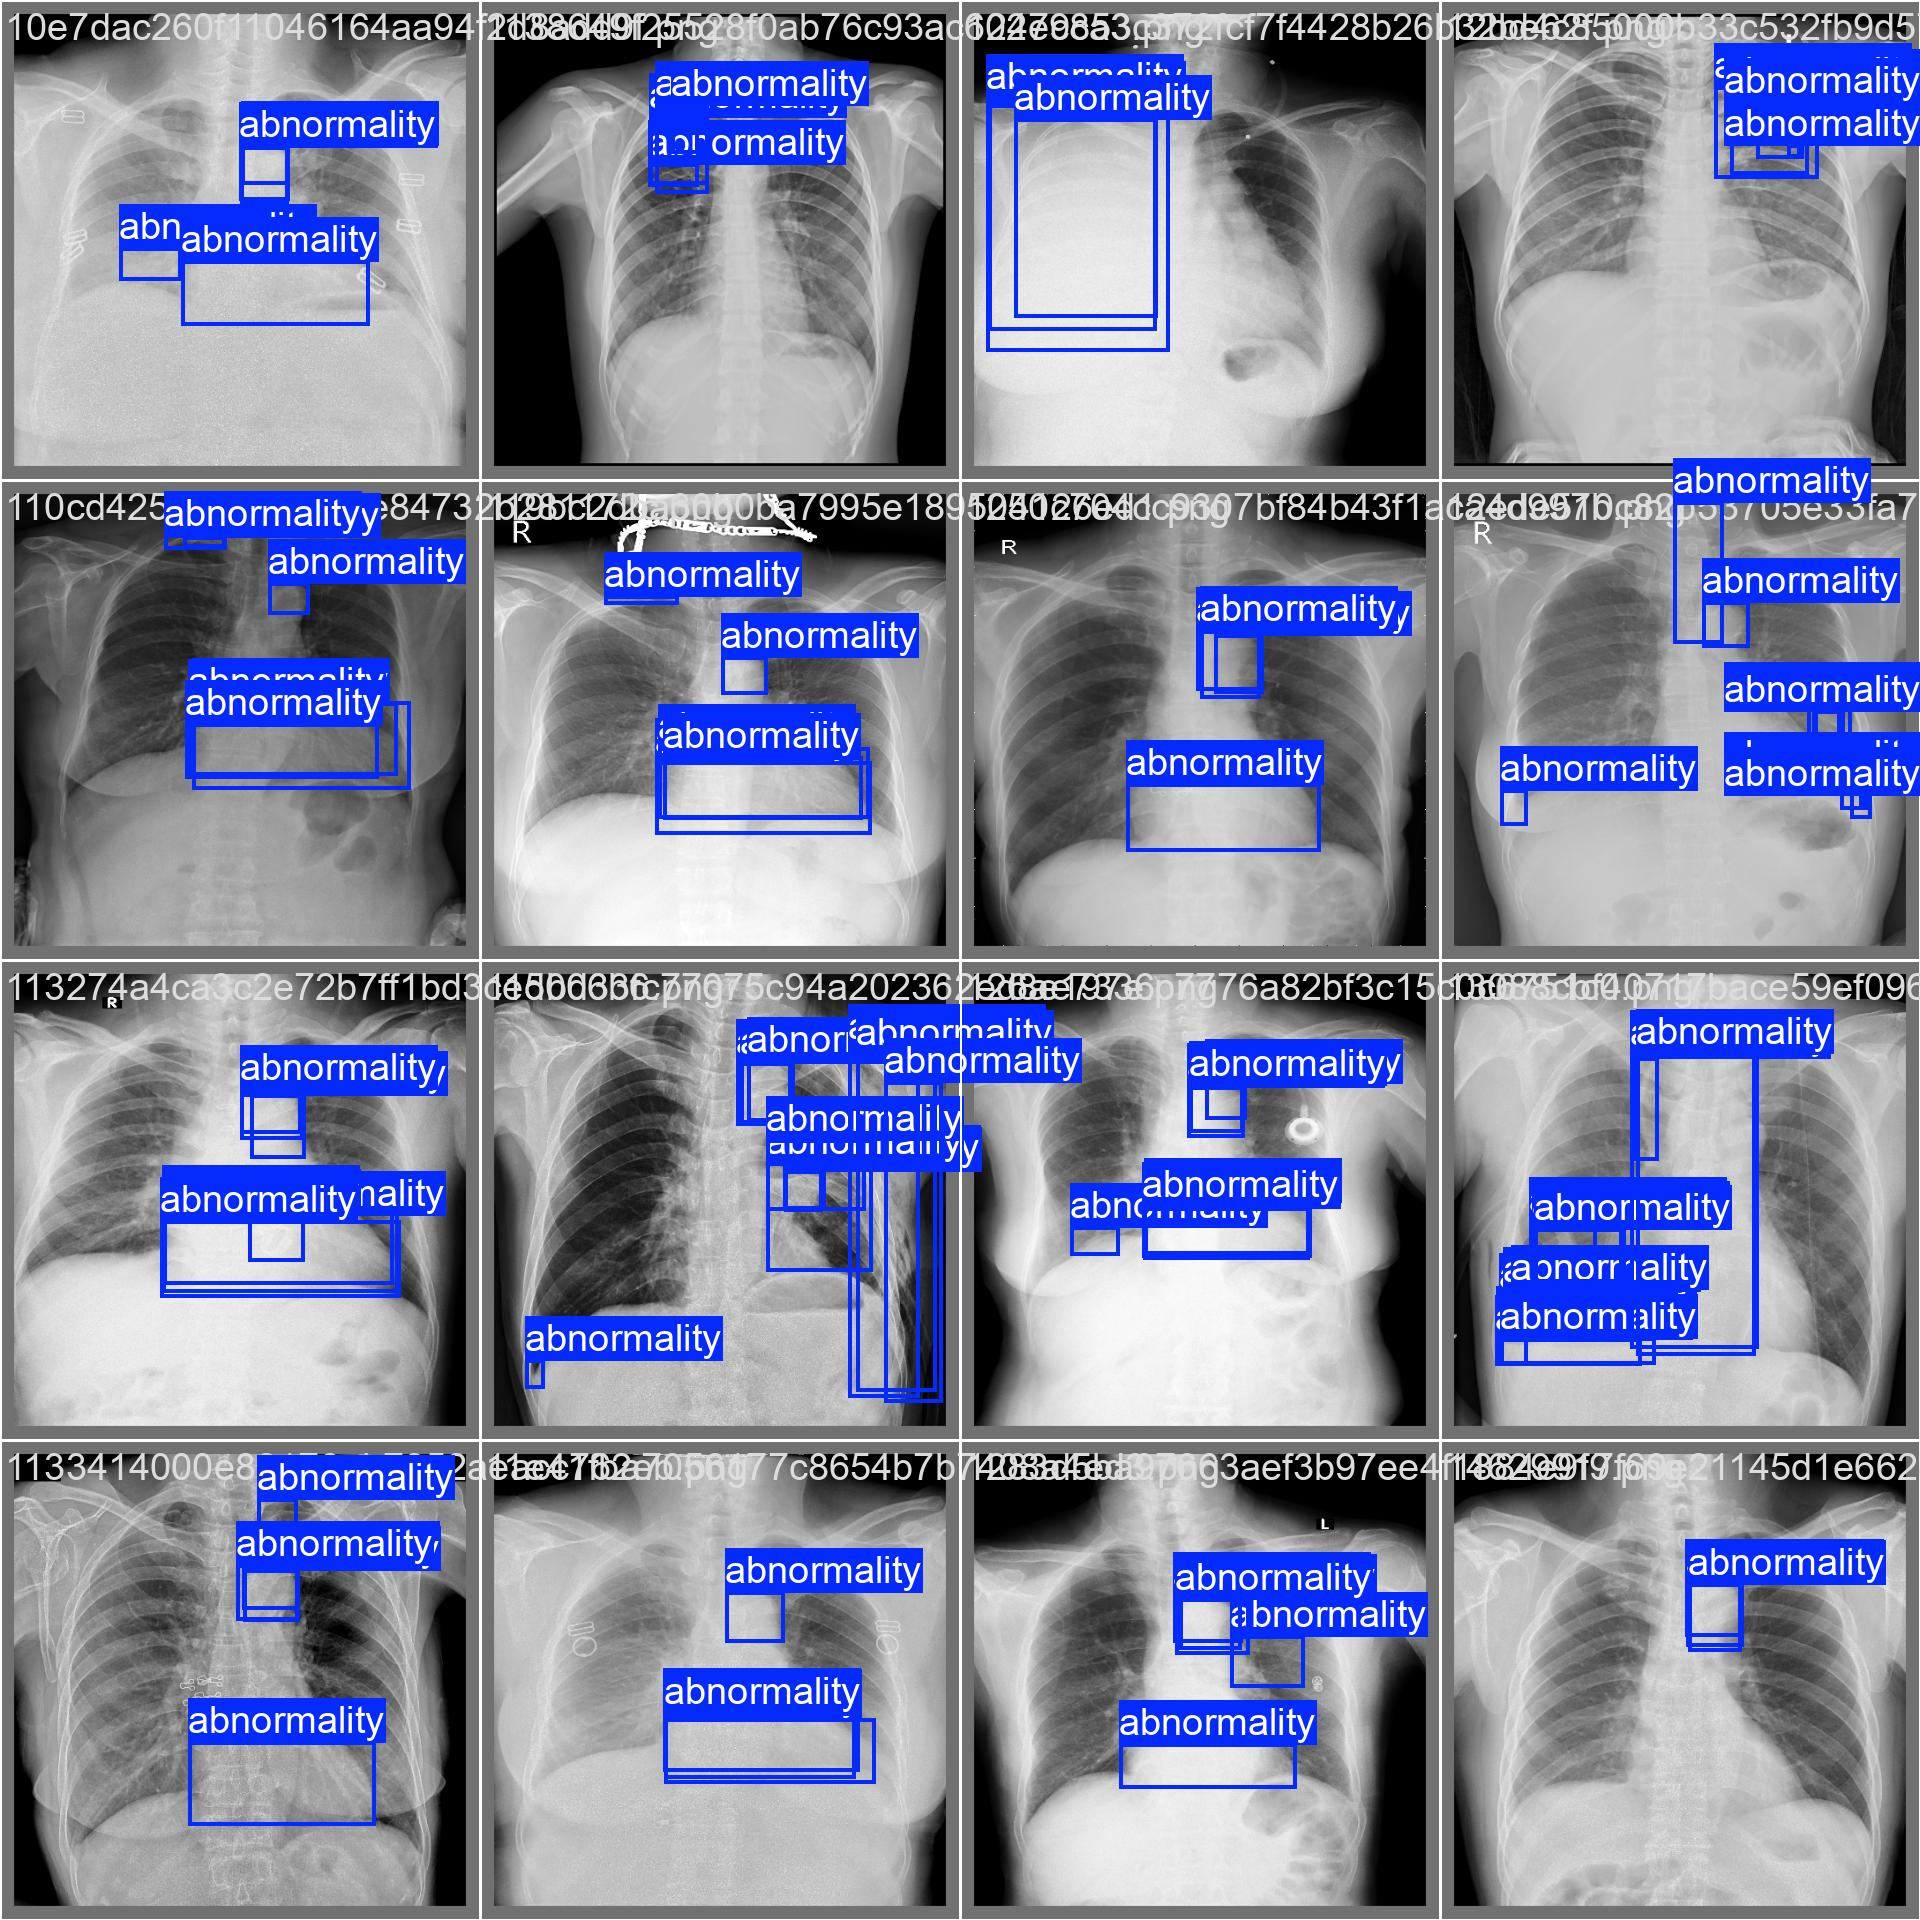

=== val_batch1_pred.jpg  [예측(Pred)] ===


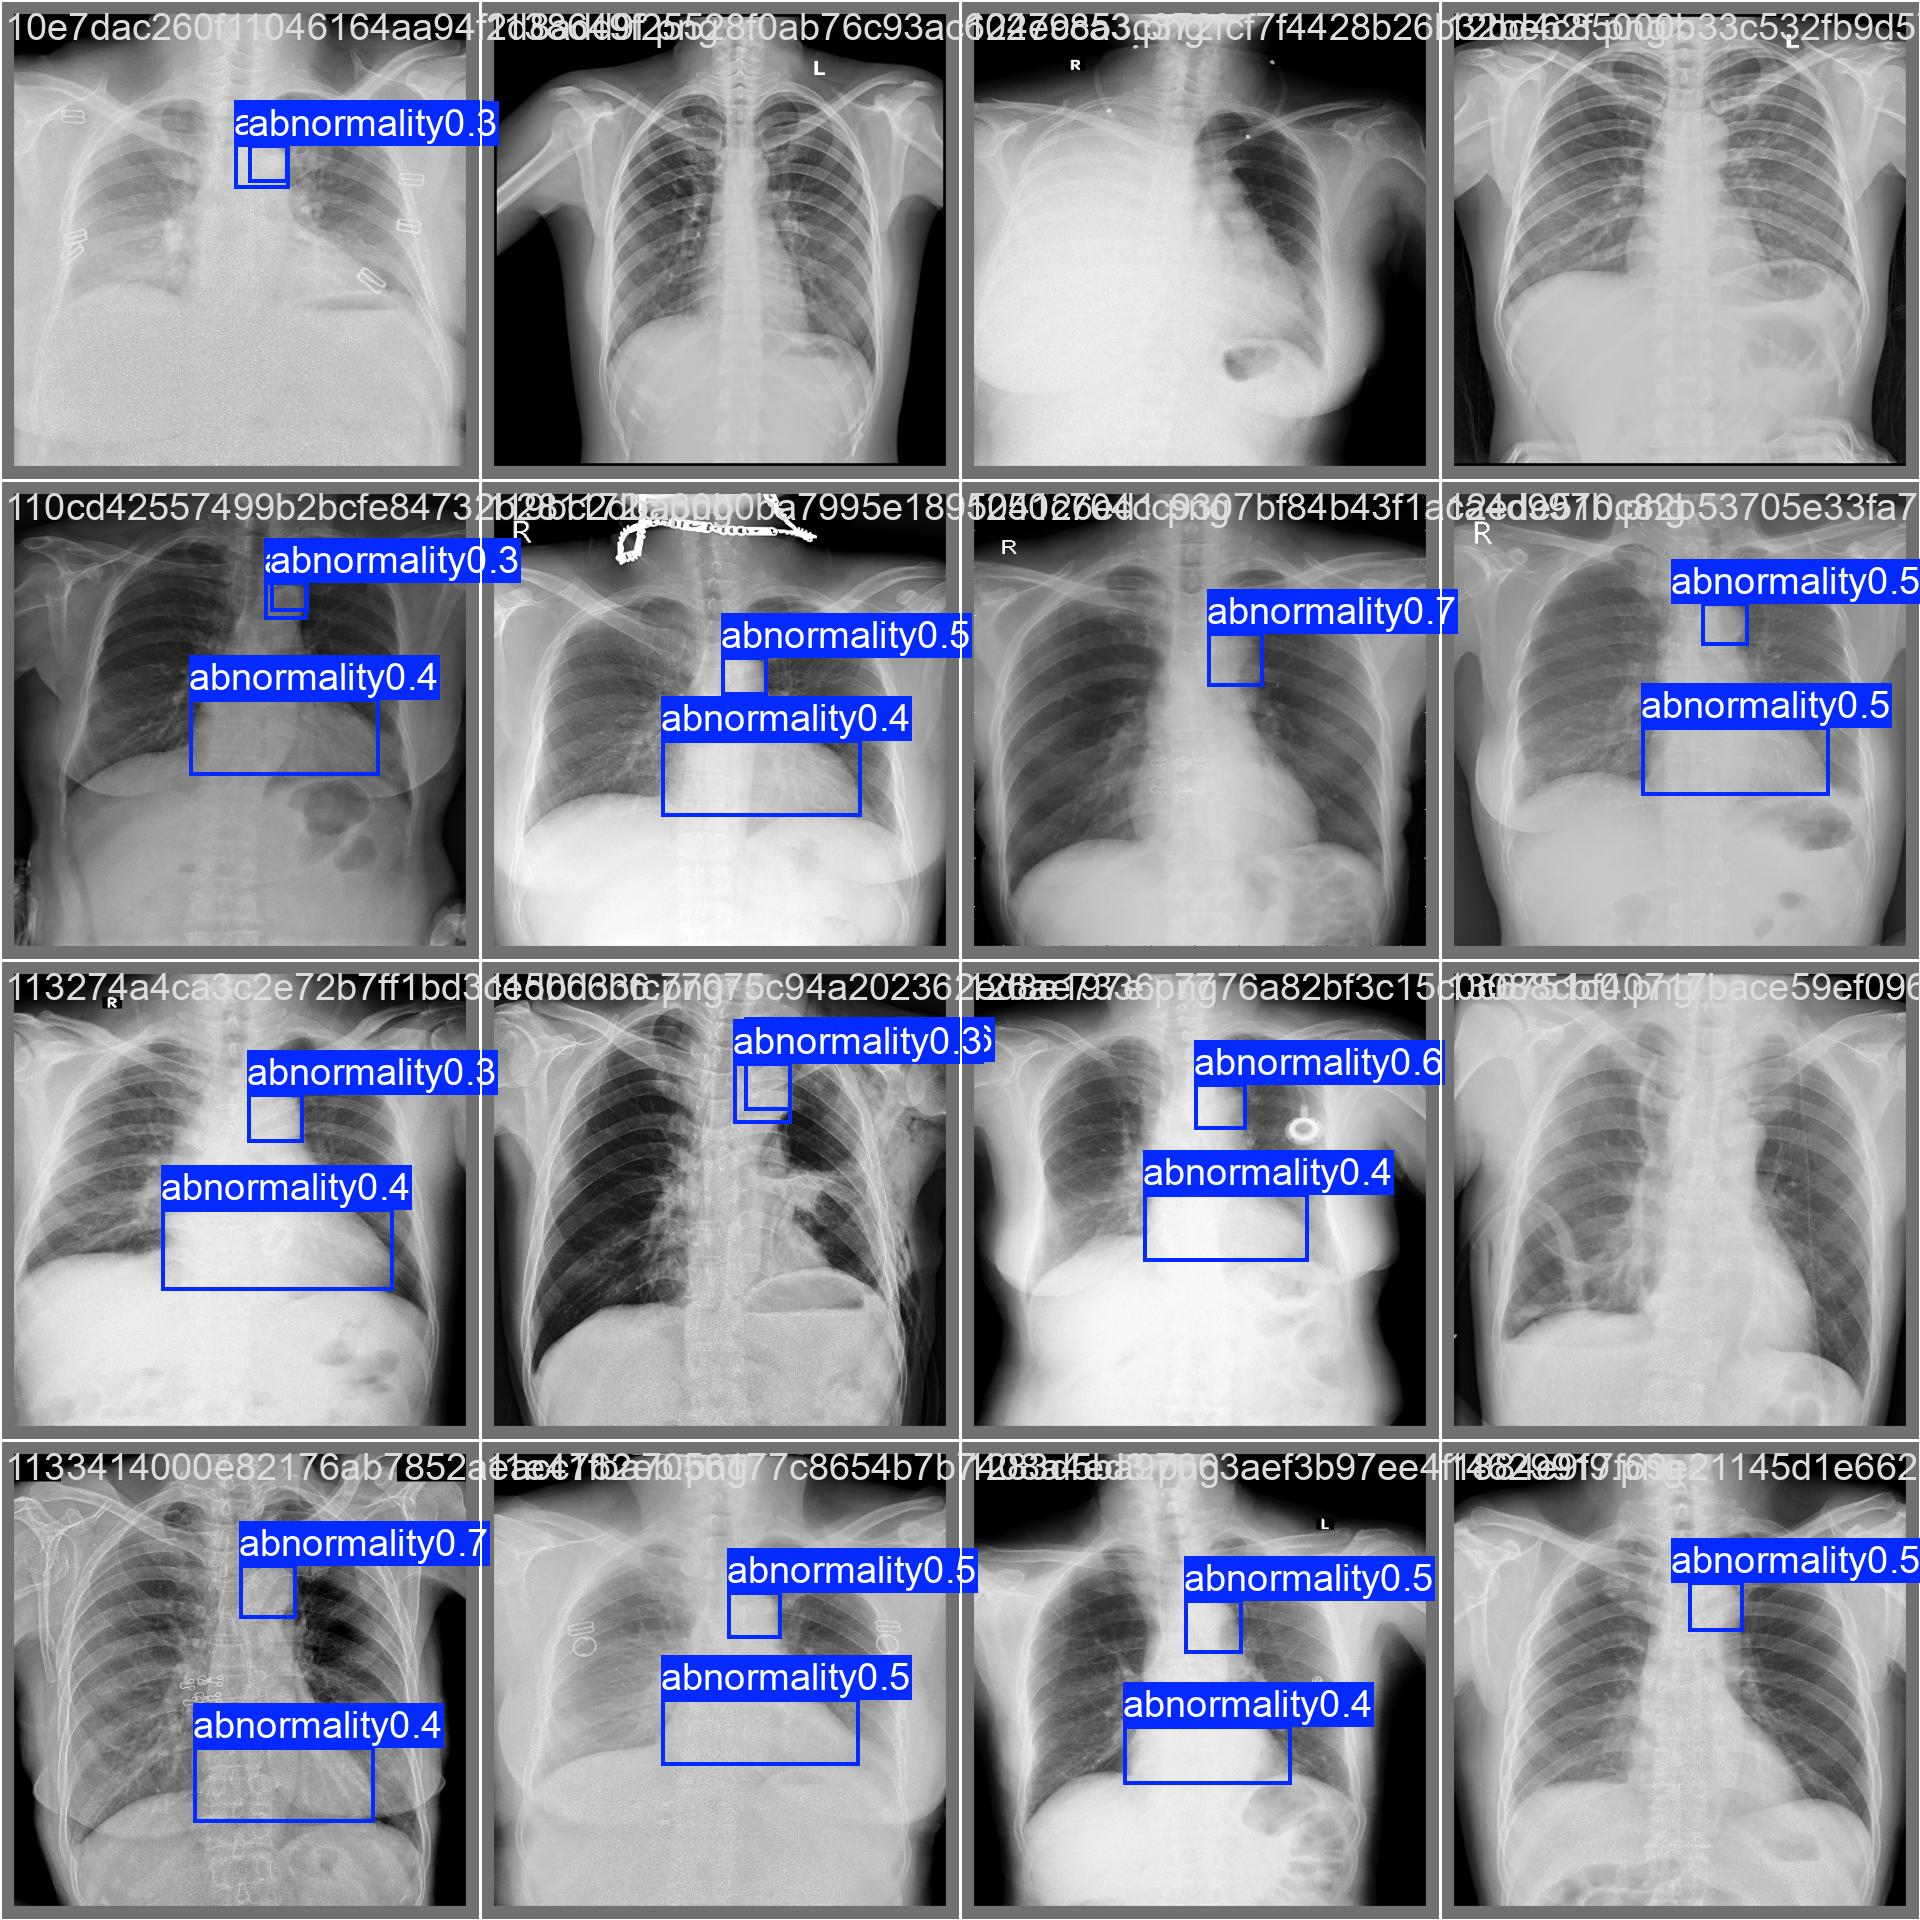

In [20]:
from IPython.display import Image as IPImage, display

# YOLO가 자동 저장한 "정답 vs 예측" 비교 이미지.
#   *_labels.jpg = 정답(ground truth),  *_pred.jpg = 모델 예측
# 같은 batch 번호끼리 나란히 보면, 무엇을 맞추고 무엇을 놓쳤는지 보입니다.
out = RUN_DIR / EXP_NAME
for batch in [0, 1]:
    for tag in ['labels', 'pred']:
        p = out / f'val_batch{batch}_{tag}.jpg'
        if p.exists():
            kind = '정답(GT)' if tag == 'labels' else '예측(Pred)'
            print(f'=== val_batch{batch}_{tag}.jpg  [{kind}] ===')
            display(IPImage(str(p)))

다중 클래스(도전과제 5) 실행 시에는, `val()` 출력에 **클래스별 AP**가 함께 나옵니다.
거기서 어떤 병변의 AP가 낮은지 보고, 3-2에서 본 클래스 개수와 연결해서 해석하세요.


0: 512x512 1 abnormality, 7.3ms
1: 512x512 2 abnormalitys, 7.3ms
2: 512x512 2 abnormalitys, 7.3ms
3: 512x512 (no detections), 7.3ms
4: 512x512 2 abnormalitys, 7.3ms
5: 512x512 2 abnormalitys, 7.3ms
Speed: 1.0ms preprocess, 7.3ms inference, 0.8ms postprocess per image at shape (1, 3, 512, 512)


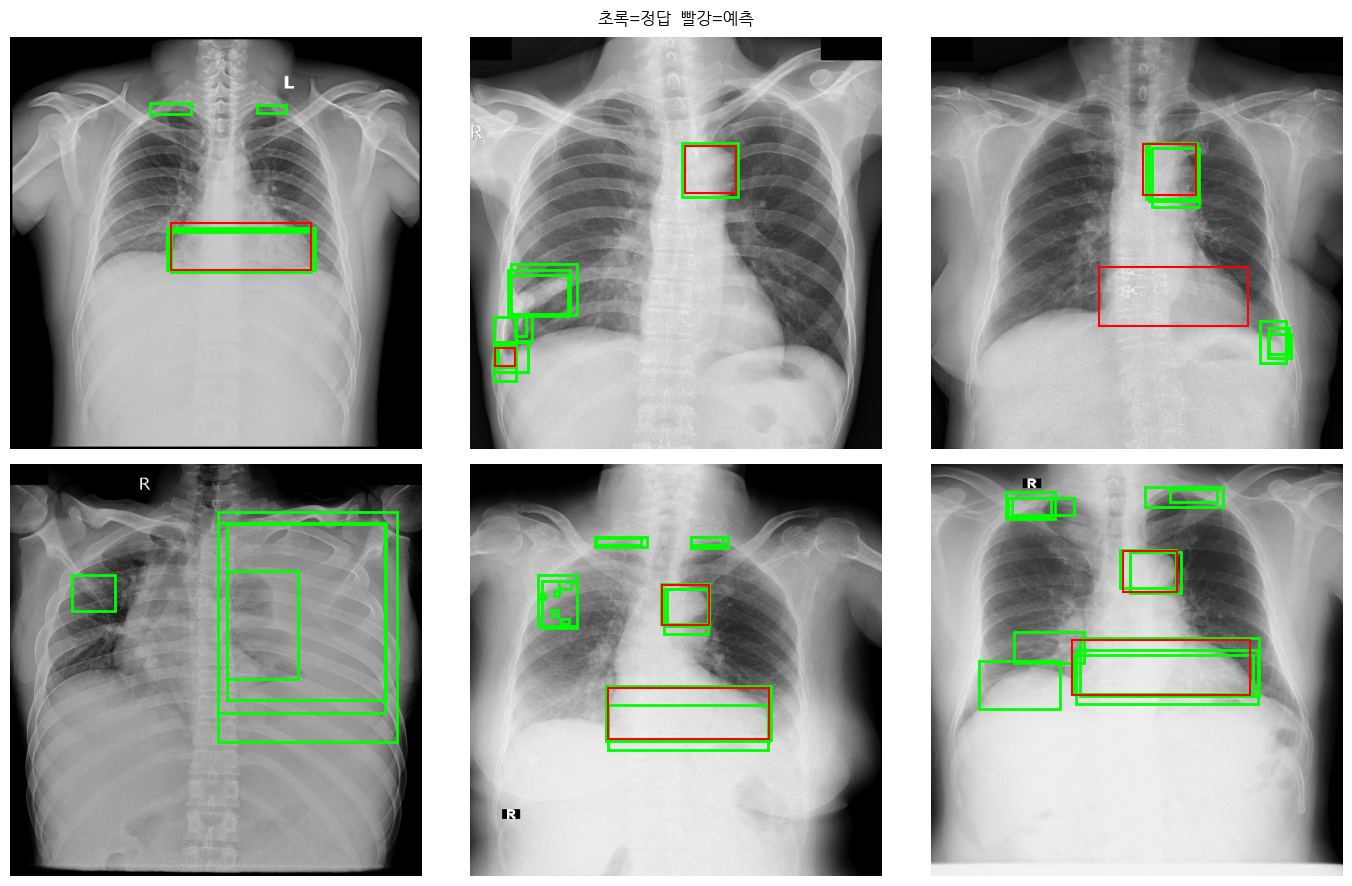

In [21]:
# 직접 녹색 진짜데이터, 빨강선 예측데이터 그려서 확인하기

# 한 장에 정답(초록) + 예측(빨강) 겹쳐 그리기
val_images = list((WORK_DIR / 'images' / 'val').glob('*.png'))
sample_imgs = random.sample(val_images, min(6, len(val_images)))

results = best_model.predict(source=[str(p) for p in sample_imgs],
                             conf=0.25, iou=0.45, save=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, r, path in zip(axes.flat, results, sample_imgs):
    img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    ax.imshow(img); ax.axis('off')

    # 정답(초록)
    lp = WORK_DIR / 'labels' / 'val' / f'{path.stem}.txt'
    if lp.exists() and lp.read_text().strip():
        for line in lp.read_text().strip().split('\n'):
            _, cx, cy, bw, bh = map(float, line.split())
            ax.add_patch(patches.Rectangle((cx*w-bw*w/2, cy*h-bh*h/2),
                         bw*w, bh*h, lw=2, edgecolor='lime', facecolor='none'))
    # 예측(빨강)
    for box in r.boxes:
        x1,y1,x2,y2 = box.xyxy[0].cpu().numpy()
        ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1,
                     lw=1.5, edgecolor='red', facecolor='none'))
plt.suptitle('초록=정답  빨강=예측', fontsize=12)
plt.tight_layout(); plt.show()

## 11. 추론 & 정성 평가

### 미션: 정답과 예측을 한 화면에서 비교한다

숫자(mAP)만으로는 모델이 *어떻게* 틀리는지 안 보입니다. 아래 셀은 한 이미지에 **정답(초록)**과 **예측(빨강)**을 겹쳐 그립니다.

- 초록과 빨강이 겹침 → 잘 맞춤
- 초록만 있음 → 병변을 놓침 (recall 손해)
- 빨강만 있음 → 헛다리, 거짓양성 (precision 손해)

confidence 숫자가 전반적으로 낮으면(0.3 미만) 학습 부족 신호입니다. `conf` 값을 0.4로 올려보며 거짓양성이 줄어드는지도 관찰해 보세요.


0: 512x512 2 abnormalitys, 3.3ms
1: 512x512 1 abnormality, 3.3ms
2: 512x512 2 abnormalitys, 3.3ms
3: 512x512 1 abnormality, 3.3ms
4: 512x512 (no detections), 3.3ms
5: 512x512 (no detections), 3.3ms
Speed: 1.0ms preprocess, 3.3ms inference, 0.7ms postprocess per image at shape (1, 3, 512, 512)


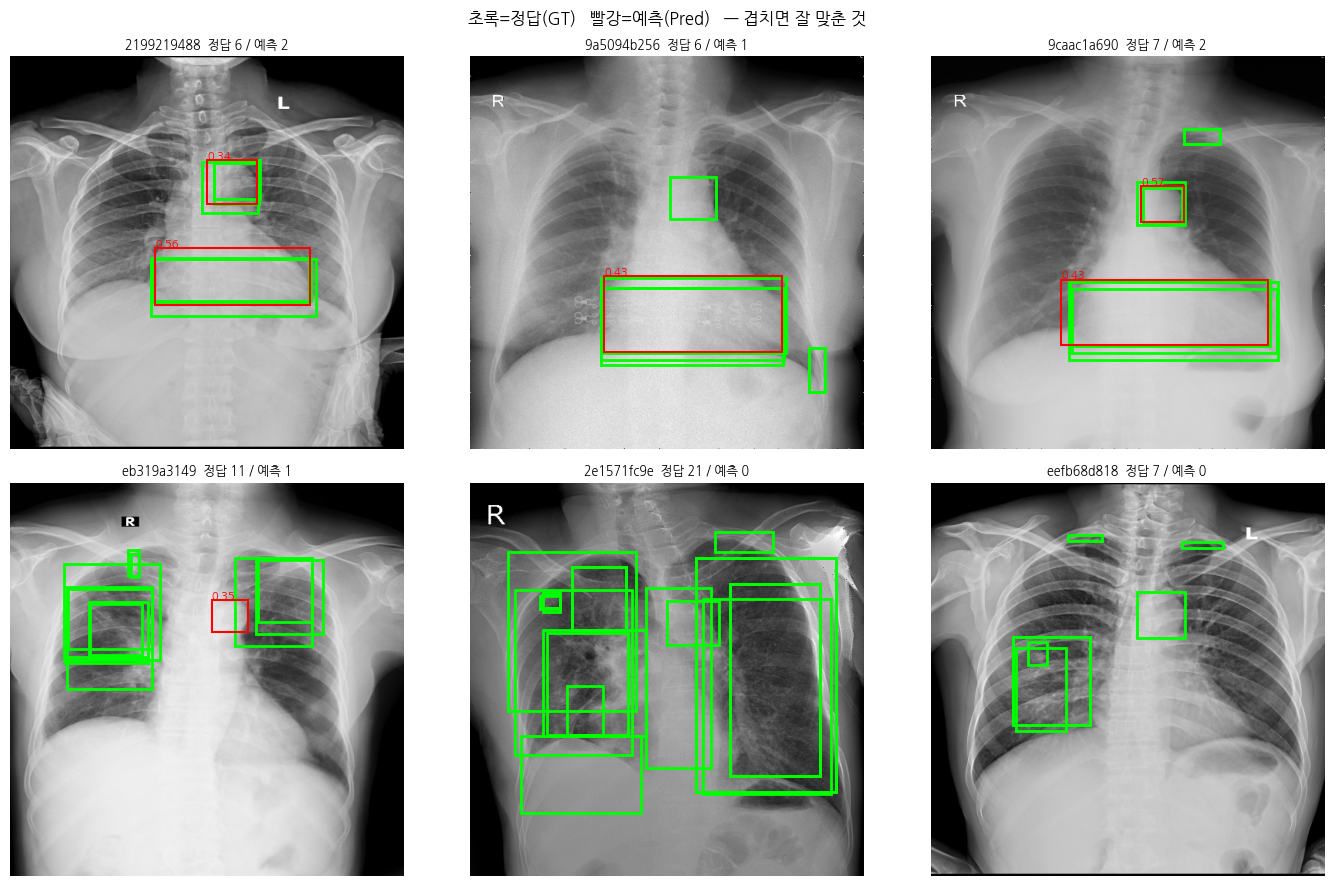

In [22]:
import random
import matplotlib.patches as patches

val_images = list((WORK_DIR / 'images' / 'val').glob('*.png'))
sample_imgs = random.sample(val_images, min(6, len(val_images)))

results = best_model.predict(
    source = [str(p) for p in sample_imgs],
    conf   = 0.25,
    iou    = 0.45,
    save   = False,
)

# 한 장에 정답(초록) + 예측(빨강)을 겹쳐 그려서 직접 비교한다.
#   초록만 있고 빨강 없음 -> 놓침(recall 손해)
#   빨강만 있고 초록 없음 -> 헛다리(거짓양성, precision 손해)
#   둘이 겹침 -> 잘 맞춘 것
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, r, path in zip(axes.flat, results, sample_imgs):
    img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    ax.imshow(img); ax.axis('off')

    # 정답(초록): labels/val 폴더의 .txt
    lp = WORK_DIR / 'labels' / 'val' / f'{path.stem}.txt'
    n_gt = 0
    if lp.exists() and lp.read_text().strip():
        for line in lp.read_text().strip().split('\n'):
            _, cx, cy, bw, bh = map(float, line.split())
            ax.add_patch(patches.Rectangle(
                (cx*w - bw*w/2, cy*h - bh*h/2), bw*w, bh*h,
                linewidth=2, edgecolor='lime', facecolor='none'))
            n_gt += 1

    # 예측(빨강)
    n_pred = len(r.boxes)
    for box in r.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        conf = float(box.conf)
        ax.add_patch(patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=1.5, edgecolor='red', facecolor='none'))
        ax.text(x1, y1-3, f'{conf:.2f}', color='red', fontsize=8)

    ax.set_title(f'{path.name[:10]}  정답 {n_gt} / 예측 {n_pred}', fontsize=9)

plt.suptitle('초록=정답(GT)   빨강=예측(Pred)   — 겹치면 잘 맞춘 것', fontsize=12)
plt.tight_layout(); plt.show()

**정성 평가 체크리스트**

- [ ] 배경(폐 바깥, 검은 영역)에 박스가 잡히는가? → 거짓양성 문제
- [ ] confidence가 전반적으로 낮은가(0.3 미만)? → 학습 부족 신호 (epoch 늘리기)
- [ ] 실제 병변이 있을 법한데 박스가 없는가? → recall 문제

> 베이스라인은 epoch 3이라 위 문제들이 다 보일 것입니다. 그게 정상이고, 도전과제들이 이걸 개선하는 과정입니다.

## 12. 다음 단계

- 베이스라인이 끝까지 돌았습니다.
- 이제 Day3_assignment.md의 과제를 하나씩 수행합니다.
- 참고로 같은 과제를 실무 티켓 형식으로 정리한 CXR-DET_tickets.md도 함께 봅니다. 현업에서는 이런 형태로 일이 내려온다는 걸 감 잡는 용도입니다.


**작업 규칙**
- 1번 설정 셀에서 **한 번에 하나의 값만** 바꿉니다.
- `EXP_NAME`을 매번 다르게 줍니다 (`runs_cxr/` 덮어쓰기 방지).
- 각 실험 후 결과를 마크다운 리포트에 기록합니다.

지금 이 baseline의 4개 지표를 결과표의 기준값으로 먼저 적어두고 시작하세요

## baseline 
IMG_SIZE  = 512
EPOCHS    = 3
BATCH     = 16
MODEL_PT  = 'yolov8n.pt'
EXP_NAME  = 'baseline'

mAP50     : 0.3031
mAP50-95  : 0.1516
Precision : 0.3865
Recall    : 0.2800

## baseline_v2
IMG_SIZE  = 512
**EPOCHS    = 5**
BATCH     = 16
MODEL_PT  = 'yolov8n.pt'
EXP_NAME  = 'baseline_v2'

mAP50     : 0.3873
mAP50-95  : 0.1973
Precision : 0.5087
Recall    : 0.3578

## baseline_v3
IMG_SIZE  = 512
EPOCHS    = 3
**BATCH     = 32**
MODEL_PT  = 'yolov8n.pt'
EXP_NAME  = 'baseline_v2'

mAP50     : 0.2802
mAP50-95  : 0.1396
Precision : 0.4528
Recall    : 0.2625